<a href="https://colab.research.google.com/github/mrigankadas743442-cpu/Vaccination_Data_Analysis_and_Visualization/blob/main/Vaccination_Data_Analysis_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  **Vaccination Data Analysis and Visualization**



##### **Project Type**    - **EDA / Data Analysis / Data Visualization**
##### **Contribution**    - Individual
##### **Team Member 1 -** Mriganka Das
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**



The project, **“Vaccination Data Analysis and Visualization,”** focuses on analyzing global vaccination-related data to understand vaccination coverage, disease incidence, reported cases, vaccine introduction, and vaccination schedules. The project combines Python, data cleaning, exploratory data analysis (EDA), SQL database design, and Power BI visualization as specified in the project requirements.

Five datasets were used in the analysis: Coverage Data, Incidence Rate Data, Reported Cases Data, Vaccine Introduction Data, and Vaccine Schedule Data. The datasets contain information about countries, years, vaccines, diseases, vaccination coverage, disease incidence, reported cases, vaccine introduction status, and target populations. The initial datasets contained hundreds of thousands of records across the five tables.

The data-wrangling process included standardizing column names, converting year fields into appropriate numeric formats, removing metadata/footer records, checking for duplicate records, identifying missing values, and investigating invalid values. Exact duplicate records were not found in the five datasets. Missing values were examined rather than being automatically replaced, because the meaning of missing observations differs across the datasets. Invalid negative dose values identified in the Coverage Data were treated as missing, while vaccination coverage values above 100% were retained and flagged rather than being removed without investigation.

Exploratory Data Analysis was performed to identify patterns and differences in vaccination coverage and disease outcomes. The analysis examined countries and antigens with comparatively low vaccination coverage, countries with high measles incidence, vaccine introduction trends, vaccination schedule target populations, and the relationship between vaccination coverage and measles outcomes. A matched country-year analysis of vaccination coverage and measles outcomes showed an inverse association between vaccination coverage and measles incidence. However, this relationship does not establish causation because disease outcomes can be influenced by multiple factors.

A normalized SQLite database was created to organize the cleaned data. Separate tables were created for Countries, Years, Diseases, Vaccines, Coverage, Incidence_Rate, Reported_Cases, Vaccine_Introduction, and Vaccine_Schedule. Primary and foreign-key relationships were implemented to reduce redundancy and maintain referential integrity. Foreign-key integrity checks were performed and no orphan records were identified in the implemented relationships.

Power BI was connected to the SQL database to create interactive dashboards. Six dashboard pages were developed: Overview, Vaccination Coverage, Disease Incidence & Cases, Vaccine Introduction & Schedule, Coverage & Incidence Relationship, and Geographical Analysis. The dashboards include KPI cards, bar charts, line charts, a scatter plot with a trend line, geographical maps, and an interactive year slicer.

Overall, the project demonstrates an end-to-end healthcare data analytics workflow from raw vaccination datasets to cleaned data, exploratory analysis, normalized SQL storage, and interactive Power BI dashboards. The resulting analysis can support monitoring of vaccination coverage, disease incidence, reported cases, vaccine introduction patterns, and vaccination schedules, while identifying areas that may require further public-health investigation and resource planning.

# **GitHub Link -**

https://github.com/mrigankadas743442-cpu/Vaccination_Data_Analysis_and_Visualization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **Problem Statement**


Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and effectiveness. The data will be cleaned and stored in a SQL database. Power BI will be used to connect to the SQL database and create interactive dashboards that provide insights on vaccination strategies and their impact on disease control.

#### **Define Your Business Objective?**

The business objective is to use vaccination and disease data to support public health strategy, disease prevention, resource allocation, and global health policy.

The analysis aims to identify areas with low vaccination coverage, examine diseases with high incidence despite vaccination efforts, understand vaccination coverage and disease trends, and provide data-driven insights for vaccination program planning and resource allocation.

The project also aims to create a structured SQL database and interactive Power BI dashboards that allow stakeholders to explore vaccination coverage, disease incidence, reported cases, vaccine introduction, and vaccination schedules.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [ ]:
# Load Dataset
base_path = "/content/drive/MyDrive/Vaccination_Data_Analysis/data/"

coverage = pd.read_excel(base_path + "coverage-data.xlsx")
incidence = pd.read_excel(base_path + "incidence-rate-data.xlsx")
reported_cases = pd.read_excel(base_path + "reported-cases-data.xlsx")
vaccine_introduction = pd.read_excel(base_path + "vaccine-introduction-data.xlsx")
vaccine_schedule = pd.read_excel(base_path + "vaccine-schedule-data.xlsx")

### Dataset First View

In [ ]:
# Dataset First Look
print("Coverage Data:", coverage.shape)
print("Incidence Rate Data:", incidence.shape)
print("Reported Cases Data:", reported_cases.shape)
print("Vaccine Introduction Data:", vaccine_introduction.shape)
print("Vaccine Schedule Data:", vaccine_schedule.shape)

### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count

datasets = {
    "Coverage Data": coverage,
    "Incidence Rate Data": incidence,
    "Reported Cases Data": reported_cases,
    "Vaccine Introduction Data": vaccine_introduction,
    "Vaccine Schedule Data": vaccine_schedule
}

for name, df in datasets.items():
    print(f"{name}:")
    print(f"  Rows    : {df.shape[0]:,}")
    print(f"  Columns : {df.shape[1]}")
    print("-" * 40)

### Dataset Information

In [ ]:

# Dataset Information

for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(f"{name}")
    print(f"{'=' * 60}")
    df.info()

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count

for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()

    print(f"{name}:")
    print(f"  Duplicate Rows: {duplicate_count:,}")
    print("-" * 40)

### Duplicate Value Analysis

The duplicate value analysis was performed on all five datasets.

The results show that there are no exact duplicate rows in any of the datasets. Therefore, no records were removed based on duplicate-row detection.

| Dataset | Duplicate Rows |
|---|---:|
| Coverage Data | 0 |
| Incidence Rate Data | 0 |
| Reported Cases Data | 0 |
| Vaccine Introduction Data | 0 |
| Vaccine Schedule Data | 0 |

The datasets can therefore proceed to the next stage of data-quality analysis.

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count

missing_summary = []

for name, df in datasets.items():
    for column in df.columns:
        missing_count = df[column].isnull().sum()
        missing_percentage = (missing_count / len(df)) * 100

        if missing_count > 0:
            missing_summary.append({
                "Dataset": name,
                "Column": column,
                "Missing Values": missing_count,
                "Missing Percentage": round(missing_percentage, 2)
            })

missing_df = pd.DataFrame(missing_summary)

missing_df

In [ ]:
# Visualizing the missing values

plt.figure(figsize=(12, 6))

sns.barplot(
    data=missing_df,
    x="Column",
    y="Missing Percentage",
    hue="Dataset"
)

plt.title("Missing Values Percentage by Dataset")
plt.xlabel("Column")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### What did you know about your dataset?



The project consists of five datasets related to vaccination coverage, disease incidence, reported cases, vaccine introduction, and vaccine schedules.

The Coverage Data contains 399,859 records and 11 columns. It has substantial missing values in TARGET_NUMBER, DOSES, and COVERAGE.

The Incidence Rate Data contains 84,946 records and 8 columns. The INCIDENCE_RATE column contains missing values.

The Reported Cases Data contains 84,870 records and 7 columns. The CASES column contains missing values.

The Vaccine Introduction Data contains 138,321 records and 6 columns and has very limited missing data.

The Vaccine Schedule Data contains 8,053 records and 12 columns. TARGETPOP, SOURCECOMMENT, and AGEADMINISTERED contain a notable proportion of missing values.

No exact duplicate rows were found in any of the five datasets.

The missing values will be investigated further before deciding whether records should be retained, removed, or handled through an appropriate cleaning strategy.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns

for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name)
    print(f"{'=' * 60}")
    print(df.columns.tolist())

In [ ]:
# Dataset Describe

for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name)
    print(f"{'=' * 60}")
    display(df.describe(include='all').T)

## **Variables Description**

### Table 1: Coverage Data

- **GROUP:** Categorization of the data. Here, it represents countries.
- **CODE:** Unique identifier for the country (ISO Alpha-3 code).
- **NAME:** Name of the country.
- **YEAR:** The year the data is recorded for.
- **ANTIGEN:** Vaccine identifier or code.
- **ANTIGEN_DESCRIPTION:** Full description of the vaccine.
- **COVERAGE_CATEGORY:** Type of coverage reported, such as administrative or official.
- **COVERAGE_CATEGORY_DESCRIPTION:** Expanded details of the coverage category.
- **TARGET_NUMBER:** Number of individuals targeted for vaccination.
- **DOSES:** Number of doses administered.
- **COVERAGE:** Percentage of the target population that was vaccinated.

### Table 2: Incidence Rate Data

- **GROUP:** Classification of the data; here, it represents countries.
- **CODE:** Unique identifier for the country (ISO Alpha-3 code).
- **NAME:** Name of the country.
- **YEAR:** The year the data is recorded for.
- **DISEASE:** Code or short name of the disease.
- **DISEASE_DESCRIPTION:** Full description of the disease.
- **DENOMINATOR:** The population basis used to calculate the incidence rate.
- **INCIDENCE_RATE:** Number of disease cases per specified population unit.

### Table 3: Reported Cases Data

- **GROUP:** Classification of the data; here, it represents countries.
- **CODE:** Unique identifier for the country (ISO Alpha-3 code).
- **NAME:** Name of the country.
- **YEAR:** The year the data is recorded for.
- **DISEASE:** Code or short name of the disease.
- **DISEASE_DESCRIPTION:** Full description of the disease.
- **CASES:** Number of reported cases of the disease for the specified year and region.

### Table 4: Vaccine Introduction Data

- **ISO_3_CODE:** Unique 3-letter ISO country code.
- **COUNTRYNAME:** Name of the country.
- **WHO_REGION:** World Health Organization (WHO) region to which the country belongs.
- **YEAR:** The year the data is recorded for.
- **DESCRIPTION:** Name of the vaccine or vaccine type.
- **INTRO:** Indicates whether the vaccine has been introduced into the country's vaccination program.

### Table 5: Vaccine Schedule Data

- **ISO_3_CODE:** Unique 3-letter ISO country code.
- **COUNTRYNAME:** Name of the country.
- **WHO_REGION:** World Health Organization (WHO) region to which the country belongs.
- **YEAR:** The year the data is recorded for.
- **VACCINECODE:** Code for the vaccine.
- **VACCINE_DESCRIPTION:** Name and details of the vaccine.
- **SCHEDULEROUNDS:** The dose or round of the vaccine in the schedule.
- **TARGETPOP:** Specific population targeted for the vaccine dose.
- **TARGETPOP_DESCRIPTION:** Detailed description of the target population.
- **GEOAREA:** Geographic area of administration.
- **AGEADMINISTERED:** Age or time of vaccine administration.
- **SOURCECOMMENT:** Additional information or context for administration.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable

for name, df in datasets.items():
    print(f"\n{'=' * 70}")
    print(f"{name}")
    print(f"{'=' * 70}")

    for column in df.columns:
        unique_count = df[column].nunique(dropna=True)

        print(f"\n{column}")
        print(f"Unique Values Count: {unique_count:,}")

        # Display actual values only when the number of unique values is manageable
        if unique_count <= 20:
            print("Unique Values:")
            print(df[column].dropna().unique())

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:


# Create copies of the original datasets
coverage_clean = coverage.copy()
incidence_clean = incidence.copy()
reported_cases_clean = reported_cases.copy()
vaccine_introduction_clean = vaccine_introduction.copy()
vaccine_schedule_clean = vaccine_schedule.copy()

print("Working copies created successfully.")

In [ ]:
# Standardize column names
# Convert all column names to uppercase and remove leading/trailing spaces

for df in [
    coverage_clean,
    incidence_clean,
    reported_cases_clean,
    vaccine_introduction_clean,
    vaccine_schedule_clean
]:
    df.columns = df.columns.str.strip().str.upper()

print("Column names standardized successfully.")

In [ ]:
# Remove completely empty rows

coverage_clean = coverage_clean.dropna(how="all").copy()
incidence_clean = incidence_clean.dropna(how="all").copy()
reported_cases_clean = reported_cases_clean.dropna(how="all").copy()
vaccine_introduction_clean = vaccine_introduction_clean.dropna(how="all").copy()
vaccine_schedule_clean = vaccine_schedule_clean.dropna(how="all").copy()

print("Completely empty rows removed.")

In [ ]:
# Check dataset dimensions after basic cleaning

print("=" * 60)
print("DATASET DIMENSIONS AFTER BASIC WRANGLING")
print("=" * 60)

datasets = {
    "Coverage Data": coverage_clean,
    "Incidence Rate Data": incidence_clean,
    "Reported Cases Data": reported_cases_clean,
    "Vaccine Introduction Data": vaccine_introduction_clean,
    "Vaccine Schedule Data": vaccine_schedule_clean
}

for name, df in datasets.items():
    print(f"{name:<30} : {df.shape}")

In [ ]:
# ==========================================
# Standardize YEAR data type
# ==========================================

for df in [
    coverage_clean,
    incidence_clean,
    reported_cases_clean,
    vaccine_introduction_clean,
    vaccine_schedule_clean
]:
    if "YEAR" in df.columns:
        df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce").astype("Int64")

print("YEAR columns standardized successfully.")

In [ ]:
# Check YEAR data types

for name, df in datasets.items():
    print(f"{name}: {df['YEAR'].dtype}")

In [ ]:
# ==========================================
# Validate YEAR ranges
# ==========================================

for name, df in datasets.items():
    print(f"\n{name}")
    print("Minimum Year:", df["YEAR"].min())
    print("Maximum Year:", df["YEAR"].max())
    print("Missing Years:", df["YEAR"].isna().sum())

In [ ]:
# ==========================================
# Inspect records with missing YEAR
# ==========================================

for name, df in datasets.items():
    missing_year_rows = df[df["YEAR"].isna()]

    print(f"\n{'=' * 60}")
    print(name)
    print(f"Missing YEAR records: {len(missing_year_rows)}")

    if len(missing_year_rows) > 0:
        display(missing_year_rows)

In [ ]:
# ==========================================
# Check metadata-like records
# ==========================================

for name, df in datasets.items():
    if "GROUP" in df.columns:
        metadata_rows = df[
            df["GROUP"].astype("string").str.startswith("Created:", na=False)
        ]

        print(f"\n{'=' * 60}")
        print(name)
        print("Metadata-like rows:", len(metadata_rows))

        if len(metadata_rows) > 0:
            display(metadata_rows.head())

In [ ]:
# ==========================================
# Remove metadata/footer records
# ==========================================

for df in [
    coverage_clean,
    incidence_clean,
    reported_cases_clean
]:
    df.drop(
        df[df["GROUP"].astype("string").str.startswith("Created:", na=False)].index,
        inplace=True
    )

# Vaccine Introduction and Vaccine Schedule
# use ISO_3_CODE because they do not have a GROUP column

for df in [
    vaccine_introduction_clean,
    vaccine_schedule_clean
]:
    df.drop(
        df[df["ISO_3_CODE"].astype("string").str.startswith("Created:", na=False)].index,
        inplace=True
    )

print("Metadata/footer records removed successfully.")

In [ ]:
# Verify that metadata rows have been removed

print("Coverage Data:", coverage_clean.shape)
print("Incidence Rate Data:", incidence_clean.shape)
print("Reported Cases Data:", reported_cases_clean.shape)
print("Vaccine Introduction Data:", vaccine_introduction_clean.shape)
print("Vaccine Schedule Data:", vaccine_schedule_clean.shape)

In [ ]:
# Re-check missing values after removing metadata/footer records

for name, df in datasets.items():
    print(f"\n{'=' * 70}")
    print(name)
    print(f"{'=' * 70}")

    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100

    missing_summary = pd.DataFrame({
        "Missing Values": missing,
        "Missing Percentage": missing_percent.round(2)
    })

    missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

    if missing_summary.empty:
        print("No missing values found.")
    else:
        print(missing_summary)

In [ ]:
# Investigate missing values in Coverage Data

coverage_missing = coverage_clean[
    coverage_clean["NAME"].isna() |
    coverage_clean["TARGET_NUMBER"].isna() |
    coverage_clean["DOSES"].isna() |
    coverage_clean["COVERAGE"].isna()
]

print("Rows with at least one missing value:", len(coverage_missing))

coverage_missing.head(20)

In [ ]:
# Compare missingness by Coverage Category

coverage_missing_by_category = (
    coverage_clean
    .assign(
        TARGET_NUMBER_MISSING=coverage_clean["TARGET_NUMBER"].isna(),
        DOSES_MISSING=coverage_clean["DOSES"].isna(),
        COVERAGE_MISSING=coverage_clean["COVERAGE"].isna()
    )
    .groupby("COVERAGE_CATEGORY")
    .agg(
        Total_Rows=("COVERAGE_CATEGORY", "size"),
        Missing_TARGET_NUMBER=("TARGET_NUMBER_MISSING", "sum"),
        Missing_DOSES=("DOSES_MISSING", "sum"),
        Missing_COVERAGE=("COVERAGE_MISSING", "sum")
    )
)

coverage_missing_by_category

In [ ]:
# Investigate Coverage missingness by GROUP

coverage_missing_by_group = (
    coverage_clean
    .assign(
        TARGET_NUMBER_MISSING=coverage_clean["TARGET_NUMBER"].isna(),
        DOSES_MISSING=coverage_clean["DOSES"].isna(),
        COVERAGE_MISSING=coverage_clean["COVERAGE"].isna()
    )
    .groupby("GROUP")
    .agg(
        Total_Rows=("GROUP", "size"),
        Missing_TARGET_NUMBER=("TARGET_NUMBER_MISSING", "sum"),
        Missing_DOSES=("DOSES_MISSING", "sum"),
        Missing_COVERAGE=("COVERAGE_MISSING", "sum")
    )
)

coverage_missing_by_group

In [ ]:
# Missing-value percentages by GROUP

coverage_missing_percentage = (
    coverage_clean
    .assign(
        TARGET_NUMBER_MISSING=coverage_clean["TARGET_NUMBER"].isna(),
        DOSES_MISSING=coverage_clean["DOSES"].isna(),
        COVERAGE_MISSING=coverage_clean["COVERAGE"].isna()
    )
    .groupby("GROUP")
    .agg(
        Total_Rows=("GROUP", "size"),
        Missing_TARGET_NUMBER=("TARGET_NUMBER_MISSING", "mean"),
        Missing_DOSES=("DOSES_MISSING", "mean"),
        Missing_COVERAGE=("COVERAGE_MISSING", "mean")
    )
)

coverage_missing_percentage[
    ["Missing_TARGET_NUMBER", "Missing_DOSES", "Missing_COVERAGE"]
] = (
    coverage_missing_percentage[
        ["Missing_TARGET_NUMBER", "Missing_DOSES", "Missing_COVERAGE"]
    ] * 100
).round(2)

coverage_missing_percentage

In [ ]:
# Check potentially invalid Coverage and DOSES values

print("Coverage values greater than 100%:")
print((coverage_clean["COVERAGE"] > 100).sum())

print("\nCoverage values less than 0%:")
print((coverage_clean["COVERAGE"] < 0).sum())

print("\nDOSES values less than 0:")
print((coverage_clean["DOSES"] < 0).sum())

print("\nTARGET_NUMBER values less than 0:")
print((coverage_clean["TARGET_NUMBER"] < 0).sum())

In [ ]:
# Display examples of potentially invalid values

print("Examples: COVERAGE > 100")
display(
    coverage_clean.loc[
        coverage_clean["COVERAGE"] > 100,
        ["GROUP", "CODE", "NAME", "YEAR", "ANTIGEN",
         "COVERAGE_CATEGORY", "TARGET_NUMBER", "DOSES", "COVERAGE"]
    ].head(20)
)

print("\nExamples: DOSES < 0")
display(
    coverage_clean.loc[
        coverage_clean["DOSES"] < 0,
        ["GROUP", "CODE", "NAME", "YEAR", "ANTIGEN",
         "COVERAGE_CATEGORY", "TARGET_NUMBER", "DOSES", "COVERAGE"]
    ].head(20)
)

## Apply the documented Coverage cleaning

In [ ]:
# Handle invalid negative DOSES values

negative_doses_count = (coverage_clean["DOSES"] < 0).sum()

coverage_clean.loc[
    coverage_clean["DOSES"] < 0,
    "DOSES"
] = np.nan

print(f"Negative DOSES values converted to missing: {negative_doses_count}")

# Flag Coverage values above 100%
coverage_clean["COVERAGE_ABOVE_100"] = (
    coverage_clean["COVERAGE"] > 100
)

print(
    "Coverage records above 100%:",
    coverage_clean["COVERAGE_ABOVE_100"].sum()
)

In [ ]:
print("Negative DOSES remaining:",
      (coverage_clean["DOSES"] < 0).sum())

print("COVERAGE values > 100 remaining:",
      (coverage_clean["COVERAGE"] > 100).sum())

print("\nNew column added:")
print("COVERAGE_ABOVE_100")

print("\nCoverage shape:")
print(coverage_clean.shape)

## Investigate Incidence Rate missing values

In [ ]:
# Investigate missing incidence rates by disease

incidence_missing_by_disease = (
    incidence_clean
    .assign(
        INCIDENCE_RATE_MISSING=incidence_clean["INCIDENCE_RATE"].isna()
    )
    .groupby(["DISEASE", "DISEASE_DESCRIPTION"])
    .agg(
        Total_Rows=("DISEASE", "size"),
        Missing_Incidence_Rate=("INCIDENCE_RATE_MISSING", "sum")
    )
)

incidence_missing_by_disease["Missing_Percentage"] = (
    incidence_missing_by_disease["Missing_Incidence_Rate"]
    / incidence_missing_by_disease["Total_Rows"]
    * 100
).round(2)

incidence_missing_by_disease

In [ ]:
# Investigate missing incidence rates by GROUP

incidence_missing_by_group = (
    incidence_clean
    .assign(
        INCIDENCE_RATE_MISSING=incidence_clean["INCIDENCE_RATE"].isna()
    )
    .groupby("GROUP")
    .agg(
        Total_Rows=("GROUP", "size"),
        Missing_Incidence_Rate=("INCIDENCE_RATE_MISSING", "sum")
    )
)

incidence_missing_by_group["Missing_Percentage"] = (
    incidence_missing_by_group["Missing_Incidence_Rate"]
    / incidence_missing_by_group["Total_Rows"]
    * 100
).round(2)

incidence_missing_by_group

In [ ]:
# Check for potentially invalid incidence-rate values

print("Negative INCIDENCE_RATE values:")
print((incidence_clean["INCIDENCE_RATE"] < 0).sum())

print("\nZero INCIDENCE_RATE values:")
print((incidence_clean["INCIDENCE_RATE"] == 0).sum())

print("\nMaximum INCIDENCE_RATE:")
print(incidence_clean["INCIDENCE_RATE"].max())

In [ ]:
# Display any negative incidence-rate records

negative_incidence = incidence_clean[
    incidence_clean["INCIDENCE_RATE"] < 0
]

print("Negative incidence-rate records:", len(negative_incidence))

display(
    negative_incidence[
        [
            "GROUP",
            "CODE",
            "NAME",
            "YEAR",
            "DISEASE",
            "DISEASE_DESCRIPTION",
            "DENOMINATOR",
            "INCIDENCE_RATE"
        ]
    ].head(20)
)

## Move to Reported Cases Data

In [ ]:
# Investigate missing reported cases by disease

reported_cases_missing_by_disease = (
    reported_cases_clean
    .assign(
        CASES_MISSING=reported_cases_clean["CASES"].isna()
    )
    .groupby(["DISEASE", "DISEASE_DESCRIPTION"])
    .agg(
        Total_Rows=("DISEASE", "size"),
        Missing_Cases=("CASES_MISSING", "sum")
    )
)

reported_cases_missing_by_disease["Missing_Percentage"] = (
    reported_cases_missing_by_disease["Missing_Cases"]
    / reported_cases_missing_by_disease["Total_Rows"]
    * 100
).round(2)

reported_cases_missing_by_disease

In [ ]:
# Investigate missing reported cases by GROUP

reported_cases_missing_by_group = (
    reported_cases_clean
    .assign(
        CASES_MISSING=reported_cases_clean["CASES"].isna()
    )
    .groupby("GROUP")
    .agg(
        Total_Rows=("GROUP", "size"),
        Missing_Cases=("CASES_MISSING", "sum")
    )
)

reported_cases_missing_by_group["Missing_Percentage"] = (
    reported_cases_missing_by_group["Missing_Cases"]
    / reported_cases_missing_by_group["Total_Rows"]
    * 100
).round(2)

reported_cases_missing_by_group

## Check invalid CASES values

In [ ]:
# Check for potentially invalid reported-case values

print("Negative CASES values:")
print((reported_cases_clean["CASES"] < 0).sum())

print("\nZero CASES values:")
print((reported_cases_clean["CASES"] == 0).sum())

print("\nMaximum CASES:")
print(reported_cases_clean["CASES"].max())

In [ ]:
# Display any negative reported-case records

negative_cases = reported_cases_clean[
    reported_cases_clean["CASES"] < 0
]

print("Negative case records:", len(negative_cases))

display(
    negative_cases[
        [
            "GROUP",
            "CODE",
            "NAME",
            "YEAR",
            "DISEASE",
            "DISEASE_DESCRIPTION",
            "CASES"
        ]
    ].head(20)
)

## Vaccine Introduction Data

In [ ]:
# Basic quality checks for Vaccine Introduction Data

print("Dataset shape:", vaccine_introduction_clean.shape)

print("\nNegative YEAR values:")
print((vaccine_introduction_clean["YEAR"] < 0).sum())

print("\nMinimum YEAR:")
print(vaccine_introduction_clean["YEAR"].min())

print("\nMaximum YEAR:")
print(vaccine_introduction_clean["YEAR"].max())

print("\nINTRO values:")
print(vaccine_introduction_clean["INTRO"].value_counts(dropna=False))

In [ ]:
# Check vaccine introduction years

print(
    vaccine_introduction_clean["YEAR"]
    .value_counts()
    .sort_index()
)

## Final dataset: Vaccine Schedule Data

In [ ]:
# Investigate missing TARGETPOP in Vaccine Schedule Data

schedule_target_missing = (
    vaccine_schedule_clean
    .assign(
        TARGETPOP_MISSING=vaccine_schedule_clean["TARGETPOP"].isna()
    )
    .groupby("TARGETPOP_DESCRIPTION", dropna=False)
    .agg(
        Total_Rows=("TARGETPOP_DESCRIPTION", "size"),
        Missing_TARGETPOP=("TARGETPOP_MISSING", "sum")
    )
)

schedule_target_missing["Missing_Percentage"] = (
    schedule_target_missing["Missing_TARGETPOP"]
    / schedule_target_missing["Total_Rows"]
    * 100
).round(2)

schedule_target_missing

In [ ]:
# Missingness by Vaccine Schedule field

schedule_missing_summary = pd.DataFrame({
    "Missing Values": vaccine_schedule_clean.isna().sum(),
    "Missing Percentage": (
        vaccine_schedule_clean.isna().mean() * 100
    ).round(2)
})

schedule_missing_summary = schedule_missing_summary[
    schedule_missing_summary["Missing Values"] > 0
]

schedule_missing_summary

In [ ]:
# Investigate missing AGEADMINISTERED by target population

schedule_age_missing = (
    vaccine_schedule_clean
    .assign(
        AGE_MISSING=vaccine_schedule_clean["AGEADMINISTERED"].isna()
    )
    .groupby("TARGETPOP_DESCRIPTION", dropna=False)
    .agg(
        Total_Rows=("TARGETPOP_DESCRIPTION", "size"),
        Missing_AGE=("AGE_MISSING", "sum")
    )
)

schedule_age_missing["Missing_Percentage"] = (
    schedule_age_missing["Missing_AGE"]
    / schedule_age_missing["Total_Rows"]
    * 100
).round(2)

schedule_age_missing

In [ ]:
# Investigate missing GEOAREA

geo_missing = vaccine_schedule_clean[
    vaccine_schedule_clean["GEOAREA"].isna()
]

print("Missing GEOAREA:", len(geo_missing))

display(
    geo_missing[
        [
            "ISO_3_CODE",
            "COUNTRYNAME",
            "WHO_REGION",
            "YEAR",
            "VACCINECODE",
            "VACCINE_DESCRIPTION",
            "TARGETPOP",
            "TARGETPOP_DESCRIPTION",
            "GEOAREA",
            "AGEADMINISTERED"
        ]
    ].head(30)
)

In [ ]:
# Investigate missing SOURCECOMMENT

sourcecomment_missing = vaccine_schedule_clean[
    vaccine_schedule_clean["SOURCECOMMENT"].isna()
]

print("Missing SOURCECOMMENT:", len(sourcecomment_missing))

display(
    sourcecomment_missing[
        [
            "ISO_3_CODE",
            "COUNTRYNAME",
            "WHO_REGION",
            "YEAR",
            "VACCINECODE",
            "VACCINE_DESCRIPTION",
            "TARGETPOP_DESCRIPTION",
            "GEOAREA",
            "AGEADMINISTERED",
            "SOURCECOMMENT"
        ]
    ].head(30)
)

In [ ]:
# Missing SOURCECOMMENT by target population

sourcecomment_missing_by_target = (
    vaccine_schedule_clean
    .assign(
        SOURCECOMMENT_MISSING=vaccine_schedule_clean["SOURCECOMMENT"].isna()
    )
    .groupby("TARGETPOP_DESCRIPTION", dropna=False)
    .agg(
        Total_Rows=("TARGETPOP_DESCRIPTION", "size"),
        Missing_SOURCECOMMENT=("SOURCECOMMENT_MISSING", "sum")
    )
)

sourcecomment_missing_by_target["Missing_Percentage"] = (
    sourcecomment_missing_by_target["Missing_SOURCECOMMENT"]
    / sourcecomment_missing_by_target["Total_Rows"]
    * 100
).round(2)

sourcecomment_missing_by_target

## Finalize Vaccine Schedule cleaning

In [ ]:
# Final missing-value summary for Vaccine Schedule Data

schedule_final_missing = pd.DataFrame({
    "Missing Values": vaccine_schedule_clean.isna().sum(),
    "Missing Percentage": (
        vaccine_schedule_clean.isna().mean() * 100
    ).round(2)
})

schedule_final_missing = schedule_final_missing[
    schedule_final_missing["Missing Values"] > 0
]

schedule_final_missing

In [ ]:
# Final validation of all cleaned datasets

final_datasets = {
    "Coverage Data": coverage_clean,
    "Incidence Rate Data": incidence_clean,
    "Reported Cases Data": reported_cases_clean,
    "Vaccine Introduction Data": vaccine_introduction_clean,
    "Vaccine Schedule Data": vaccine_schedule_clean
}

for name, df in final_datasets.items():
    print(f"\n{'=' * 70}")
    print(name)
    print(f"{'=' * 70}")

    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Missing values:", df.isna().sum().sum())

### What all manipulations have you done and insights you found?



The following data manipulations and validations were performed on the five vaccination datasets:

1. Created working copies of all five datasets to preserve the original data.
2. Standardized column names by removing extra spaces and converting them to uppercase.
3. Removed metadata/footer records containing `Created: ... UTC`.
4. Standardized the `YEAR` column into an integer-compatible format.
5. Checked all datasets for duplicate records; no exact duplicate rows were found.
6. Performed detailed missing-value analysis for all datasets.
7. Retained legitimate missing values as `NaN` instead of incorrectly replacing them with zero or arbitrary values.
8. In the Coverage Data, identified **8 negative DOSES values** as invalid and converted them to missing values.
9. Identified **5,097 Coverage records above 100%**. These values were retained rather than deleted or capped, and a `COVERAGE_ABOVE_100` quality flag was created for further investigation.
10. Verified that the Incidence Rate and Reported Cases datasets contain no negative values.
11. Preserved valid zero values in incidence rates and reported cases because zero can represent a genuine observation.
12. Investigated missing values by disease, group, and target population to understand their distribution.
13. Preserved all Vaccine Introduction categories without arbitrarily changing their meanings.
14. Preserved Vaccine Schedule age information in its original format because it contains weeks, months, years, and age ranges.
15. No unsupported assumptions were made while handling missing values.

### Key Insights Found

- Missing data is substantial in several analytical fields, particularly `TARGET_NUMBER`, `DOSES`, and `COVERAGE` in the Coverage Data.
- **5,097 Coverage records** contain values above 100%, indicating potential source-data or reporting issues that require further investigation.
- **8 negative DOSES values** were identified and treated as invalid.
- Incidence Rate and Reported Cases contain many zero values, which were retained as potentially valid observations.
- Missing values in Vaccine Schedule are particularly concentrated in the **General/routine** target-population category.
- Vaccine Introduction Data contains no missing values after metadata/footer removal.
- The datasets cover different time periods, so subsequent time-based analysis must consider the available period of each dataset.

Overall, the datasets were cleaned and quality-checked while preserving the original analytical meaning of valid observations and avoiding unsupported assumptions or arbitrary imputation.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Chart 1: Vaccination Coverage Trend Over Time

In [ ]:
# Chart 1: Vaccination Coverage Trend Over Time

# Use country-level coverage records with valid coverage percentages
coverage_trend = coverage_clean[
    (coverage_clean["GROUP"] == "COUNTRIES") &
    (coverage_clean["COVERAGE"].notna()) &
    (coverage_clean["COVERAGE"] >= 0) &
    (coverage_clean["COVERAGE"] <= 100)
].copy()

# Calculate yearly median vaccination coverage
coverage_yearly = (
    coverage_trend
    .groupby("YEAR", as_index=False)["COVERAGE"]
    .median()
)

# Plot the trend
plt.figure(figsize=(14, 6))

plt.plot(
    coverage_yearly["YEAR"],
    coverage_yearly["COVERAGE"],
    marker="o",
    linewidth=2
)

plt.title("Vaccination Coverage Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Median Vaccination Coverage (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because the project report requires analysis of vaccination coverage trends over multiple years. A line chart is suitable for showing how vaccination coverage changes over time and makes it easy to identify periods of increase, stability, and decline.

The chart shows the median vaccination coverage across country-level records for each year, providing a clear overall view of the long-term vaccination coverage trend.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong overall increase in median vaccination coverage from approximately 44% in 1980 to around 90% by the mid-1990s.

Coverage remained relatively high and stable at approximately 90%–93% during much of the 2000s and 2010s, reaching its highest level of about 93% around 2006–2009.

A noticeable decline can be observed after 2019, with median coverage falling to approximately 87%–88% during 2020–2023.

Overall, the chart indicates substantial long-term improvement in vaccination coverage, followed by a recent decline that may require further investigation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can support positive public-health impact by helping health organizations identify long-term vaccination trends and recognize periods where vaccination coverage has declined. The information can support resource planning, vaccination program monitoring, and targeted interventions.

The decline in median vaccination coverage after 2019 represents a negative trend in vaccination coverage. Coverage decreased from above 90% in the preceding years to approximately 87%–88% by 2020–2023. This indicates that further investigation may be required to understand the factors associated with the decline and to support efforts to improve vaccination coverage.

However, this chart is descriptive and does not establish the specific cause of the decline.

### Chart 2: Measles Incidence Rate Trend Over Time

In [ ]:
# Chart 2: Measles Incidence Rate Trend Over Time

measles_incidence = incidence_clean[
    (incidence_clean["GROUP"] == "COUNTRIES") &
    (incidence_clean["DISEASE"] == "MEASLES") &
    (incidence_clean["INCIDENCE_RATE"].notna()) &
    (incidence_clean["INCIDENCE_RATE"] >= 0)
].copy()

# Calculate yearly median incidence rate
measles_yearly = (
    measles_incidence
    .groupby("YEAR", as_index=False)["INCIDENCE_RATE"]
    .median()
)

# Plot the trend
plt.figure(figsize=(14, 6))

plt.plot(
    measles_yearly["YEAR"],
    measles_yearly["INCIDENCE_RATE"],
    marker="o",
    linewidth=2
)

plt.title("Measles Incidence Rate Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Median Incidence Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because the project report requires analysis of disease incidence trends over time. A line chart clearly shows how the median country-level measles incidence rate changes across the available years.

Measles was selected because it is included in the Incidence Rate dataset and is specifically mentioned in the project's scenario-based analysis.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong long-term decline in the median measles incidence rate.

The median incidence rate was above 800 in the early 1980s, then declined substantially during the 1980s and early 1990s. By the mid-1990s, the median incidence rate had fallen to below 50.

From approximately 2000 onward, the median incidence rate remained very low compared with the levels observed in the 1980s, with values generally close to zero in the later years.

Overall, the chart shows a substantial reduction in the median country-level measles incidence rate over the observed period. However, this descriptive trend alone does not establish that vaccination was the sole cause of the reduction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The observed decline in measles incidence can help public-health organizations monitor long-term disease trends, evaluate vaccination-program performance, and identify periods or regions that may require additional attention.

The very low incidence rates observed in the later years represent a favorable public-health trend. However, the analysis also shows that incidence was substantially higher during the earlier years, demonstrating the importance of continued disease surveillance and vaccination efforts.

The chart alone cannot identify the specific causes of the decline, so further analysis combining vaccination coverage, reported cases, and vaccine-introduction data is required.

### Chart 3: Reported Measles Cases Trend Over Time

In [ ]:
# Chart 3: Reported Measles Cases Trend Over Time

measles_cases = reported_cases_clean[
    (reported_cases_clean["GROUP"] == "COUNTRIES") &
    (reported_cases_clean["DISEASE"] == "MEASLES") &
    (reported_cases_clean["CASES"].notna()) &
    (reported_cases_clean["CASES"] >= 0)
].copy()

# Calculate yearly median reported cases
measles_cases_yearly = (
    measles_cases
    .groupby("YEAR", as_index=False)["CASES"]
    .median()
)

# Plot the trend
plt.figure(figsize=(14, 6))

plt.plot(
    measles_cases_yearly["YEAR"],
    measles_cases_yearly["CASES"],
    marker="o",
    linewidth=2
)

plt.title("Reported Measles Cases Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Median Reported Cases")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because the project report requires analysis of disease case trends over multiple years. A line chart is suitable for showing changes in reported measles cases over time and makes it easy to identify periods of increase, decrease, and relative stability.

The median number of reported cases across country-level records was used for each year to provide a comparable summary while reducing the influence of extreme country-level observations.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong long-term decline in the median number of reported measles cases.

The median reported cases were approximately 3,200 in 1980 and reached a peak of about 3,500 in 1981. After that, the number of reported cases generally declined, although some temporary increases can be observed during the 1980s and 1990s.

By the mid-1990s, the median reported cases had fallen to below 200. From approximately 2000 onward, the median remained very low compared with the levels observed during the 1980s, generally staying close to zero in the later years.

Overall, the chart indicates a substantial long-term reduction in reported measles cases across the country-level records in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can support positive public-health impact by helping health organizations monitor disease burden over time, evaluate changes in reported cases, and identify periods or regions that may require additional vaccination and disease-control attention.

The long-term decline in reported measles cases represents a favorable public-health trend. However, the temporary increases visible in some years show that disease cases did not decline continuously and that continued surveillance is important.

The chart is descriptive and does not establish that vaccination alone caused the reduction in reported cases. Further analysis combining vaccination coverage, incidence rates, and vaccine-introduction data is required to examine their relationship.

### Chart 4: Vaccination Coverage by WHO Region

In [ ]:
# Chart 4: Vaccination Coverage by WHO Region

# Select WHO regional records for the latest available year
regional_coverage = coverage_clean[
    (coverage_clean["GROUP"] == "WHO_REGIONS") &
    (coverage_clean["YEAR"] == coverage_clean["YEAR"].max()) &
    (coverage_clean["COVERAGE"].notna()) &
    (coverage_clean["COVERAGE"] >= 0) &
    (coverage_clean["COVERAGE"] <= 100)
].copy()

# Calculate median coverage for each WHO region
regional_summary = (
    regional_coverage
    .groupby("NAME", as_index=False)["COVERAGE"]
    .median()
    .sort_values("COVERAGE", ascending=False)
)

# Plot regional comparison
plt.figure(figsize=(12, 6))

plt.bar(
    regional_summary["NAME"],
    regional_summary["COVERAGE"]
)

plt.title(
    f"Vaccination Coverage by WHO Region ({regional_coverage['YEAR'].max()})"
)
plt.xlabel("WHO Region")
plt.ylabel("Median Vaccination Coverage (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because the objective is to compare vaccination coverage across different WHO regions for the latest available year. A bar chart makes differences between regions easy to identify and supports the project's requirement to analyze regional disparities in vaccination coverage.

The 2023 data was used because it is the latest available year in the Coverage Data.

##### 2. What is/are the insight(s) found from the chart?

The chart shows clear differences in median vaccination coverage across WHO regions in 2023.

The European Region has the highest median vaccination coverage at approximately 89%, followed by the Western Pacific Region at approximately 79%.

The Region of the Americas and South-East Asia Region show similar median coverage levels of approximately 76% and 75%, respectively.

The Eastern Mediterranean Region has a lower median coverage of approximately 54%, while the African Region has the lowest median coverage at approximately 48%.

Overall, the chart indicates substantial regional variation in vaccination coverage, with the African and Eastern Mediterranean Regions showing considerably lower median coverage than the European Region.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can support positive public-health impact by helping health organizations identify regions with comparatively lower vaccination coverage and prioritize further investigation, resource planning, and vaccination-support activities.

The comparatively low median coverage observed in the African and Eastern Mediterranean Regions represents an area requiring attention. The regional differences can help public-health organizations identify where additional vaccination efforts may be needed.

However, the chart is descriptive and does not explain the causes of the regional differences. Further analysis of country-level coverage, disease incidence, vaccine introduction, and other available variables is required before drawing conclusions about the reasons for these differences.

### Chart 5: Measles Incidence Rate by WHO Region

In [ ]:
# Chart 5: Measles Incidence Rate by WHO Region

# Select WHO regional measles incidence records for the latest available year
regional_measles = incidence_clean[
    (incidence_clean["GROUP"] == "WHO_REGIONS") &
    (incidence_clean["DISEASE"] == "MEASLES") &
    (incidence_clean["YEAR"] == incidence_clean["YEAR"].max()) &
    (incidence_clean["INCIDENCE_RATE"].notna()) &
    (incidence_clean["INCIDENCE_RATE"] >= 0)
].copy()

# Calculate median incidence rate for each WHO region
regional_measles_summary = (
    regional_measles
    .groupby("NAME", as_index=False)["INCIDENCE_RATE"]
    .median()
    .sort_values("INCIDENCE_RATE", ascending=False)
)

# Plot regional comparison
plt.figure(figsize=(12, 6))

plt.bar(
    regional_measles_summary["NAME"],
    regional_measles_summary["INCIDENCE_RATE"]
)

plt.title(
    f"Measles Incidence Rate by WHO Region ({regional_measles['YEAR'].max()})"
)
plt.xlabel("WHO Region")
plt.ylabel("Median Measles Incidence Rate")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because the purpose is to compare measles incidence rates across different WHO regions for the latest available year. A bar chart makes the differences between regions easy to compare and supports the project's requirement to analyze regional disparities in disease incidence.

Measles was selected because it is included in the Incidence Rate dataset and is specifically mentioned in the project's scenario-based analysis.

##### 2. What is/are the insight(s) found from the chart?

The chart shows substantial differences in median measles incidence rates across WHO regions in 2023.

The African Region has the highest median measles incidence rate at approximately 344, followed by the Eastern Mediterranean Region at approximately 123.

The European Region has a median incidence rate of approximately 71, while the South-East Asia Region is approximately 41.

The Western Pacific Region has a very low median incidence rate of approximately 3, and the Region of the Americas has a median value close to 0.

Overall, the chart indicates considerable regional disparity in measles incidence, with the African Region showing a substantially higher median incidence rate than the other WHO regions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can support positive public-health impact by helping health organizations identify regions with comparatively high measles incidence and prioritize further investigation, disease surveillance, vaccination planning, and resource allocation.

The relatively high incidence observed in the African and Eastern Mediterranean Regions represents an area requiring attention. The large regional differences can help public-health organizations focus further analysis on areas with higher disease burden.

However, this chart is descriptive and does not establish the causes of the regional differences or prove that vaccination coverage is responsible for the observed incidence levels. Further analysis combining vaccination coverage and disease incidence is required.

### Chart 6: Vaccination Coverage vs. Measles Incidence Rate

In [ ]:
# Chart 6: Vaccination Coverage vs. Measles Incidence Rate

# Prepare country-year vaccination coverage
coverage_relationship = coverage_clean[
    (coverage_clean["GROUP"] == "COUNTRIES") &
    (coverage_clean["COVERAGE"].notna()) &
    (coverage_clean["COVERAGE"] >= 0) &
    (coverage_clean["COVERAGE"] <= 100)
].copy()

# Calculate median vaccination coverage for each country and year
coverage_relationship = (
    coverage_relationship
    .groupby(["CODE", "NAME", "YEAR"], as_index=False)["COVERAGE"]
    .median()
)

# Prepare country-year measles incidence
measles_relationship = incidence_clean[
    (incidence_clean["GROUP"] == "COUNTRIES") &
    (incidence_clean["DISEASE"] == "MEASLES") &
    (incidence_clean["INCIDENCE_RATE"].notna()) &
    (incidence_clean["INCIDENCE_RATE"] >= 0)
].copy()

measles_relationship = (
    measles_relationship
    .groupby(["CODE", "NAME", "YEAR"], as_index=False)["INCIDENCE_RATE"]
    .median()
)

# Merge vaccination coverage with measles incidence
relationship_data = pd.merge(
    coverage_relationship,
    measles_relationship,
    on=["CODE", "NAME", "YEAR"],
    how="inner"
)

print("Matched country-year observations:", len(relationship_data))

# Calculate correlations
pearson_corr = relationship_data["COVERAGE"].corr(
    relationship_data["INCIDENCE_RATE"],
    method="pearson"
)

spearman_corr = relationship_data["COVERAGE"].corr(
    relationship_data["INCIDENCE_RATE"],
    method="spearman"
)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

# Scatter plot
plt.figure(figsize=(12, 7))

plt.scatter(
    relationship_data["COVERAGE"],
    relationship_data["INCIDENCE_RATE"],
    alpha=0.35
)

plt.title("Vaccination Coverage vs. Measles Incidence Rate")
plt.xlabel("Median Vaccination Coverage (%)")
plt.ylabel("Median Measles Incidence Rate")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected because the purpose of this analysis is to examine the relationship between vaccination coverage and measles incidence rate across matched country-year observations.

A scatter plot allows the distribution of individual observations to be visualized and helps assess whether higher vaccination coverage is associated with lower measles incidence. Pearson and Spearman correlation coefficients were also calculated to quantify the strength and direction of the relationship.

##### 2. What is/are the insight(s) found from the chart?

The analysis was based on 7,943 matched country-year observations.

The Pearson correlation coefficient is -0.229, indicating a weak negative linear relationship between vaccination coverage and measles incidence rate.

The Spearman correlation coefficient is -0.461, indicating a moderate negative monotonic relationship between the two variables.

Therefore, the results show that higher vaccination coverage is generally associated with lower measles incidence in the matched observations, although the relationship is not strong enough to indicate that vaccination coverage alone explains the variation in measles incidence.

The difference between the Pearson and Spearman correlations also suggests that the relationship is not fully captured by a simple linear pattern.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights can help create a positive public-health impact by showing an inverse relationship between vaccination coverage and measles incidence. The Pearson correlation of -0.229 and Spearman correlation of -0.461 indicate that higher vaccination coverage is generally associated with lower measles incidence in the analyzed country-year observations.

This insight can support vaccination-program monitoring, resource allocation, and identification of areas that may require further investigation or intervention.

The analysis also highlights a potential negative concern: the relationship is not strong enough to conclude that vaccination coverage alone explains differences in measles incidence. Other factors may contribute to disease incidence. Therefore, relying on vaccination coverage alone for decision-making could overlook other important factors.

Overall, the results provide useful evidence for further public-health analysis, but they should be interpreted as correlation rather than proof of causation.

### Chart 7: Lowest Vaccination Coverage by Country (2023)

In [ ]:
# Chart 7: Lowest Vaccination Coverage by Country (2023)

# Select country-level coverage records for 2023
low_coverage_data = coverage_clean[
    (coverage_clean["GROUP"] == "COUNTRIES") &
    (coverage_clean["YEAR"] == 2023) &
    (coverage_clean["COVERAGE"].notna()) &
    (coverage_clean["COVERAGE"] >= 0) &
    (coverage_clean["COVERAGE"] <= 100)
].copy()

# Calculate median vaccination coverage for each country
country_coverage_summary = (
    low_coverage_data
    .groupby(["CODE", "NAME"], as_index=False)["COVERAGE"]
    .median()
    .sort_values("COVERAGE", ascending=True)
)

# Select the 10 countries with the lowest median coverage
lowest_10_countries = country_coverage_summary.head(10)

# Display the values used in the chart
display(lowest_10_countries)

# Plot
plt.figure(figsize=(12, 7))

plt.barh(
    lowest_10_countries["NAME"],
    lowest_10_countries["COVERAGE"]
)

plt.title("10 Countries with Lowest Median Vaccination Coverage (2023)")
plt.xlabel("Median Vaccination Coverage (%)")
plt.ylabel("Country")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because the objective is to compare vaccination coverage across countries and identify countries with the lowest coverage. A horizontal bar chart makes it easier to read the country names and compare their vaccination coverage percentages.

The analysis focuses on the 10 countries with the lowest median vaccination coverage in 2023, directly supporting the project's requirement to identify low-coverage areas for resource allocation and public-health planning.

##### 2. What is/are the insight(s) found from the chart?

The analysis identified substantial differences in median vaccination coverage among the 10 selected countries in 2023.

French Polynesia had the lowest median vaccination coverage at 10.00%, followed by the Democratic People's Republic of Korea at 16.29% and New Caledonia at 36.75%.

Papua New Guinea had a median coverage of 41.62%, while Somalia and Sudan had approximately 46.55% and 51.00%, respectively.

Venezuela had a median coverage of 54.05%, followed by Guinea at 60.00%, Montenegro at 60.32%, and Nigeria at 62.00%.

Overall, the chart highlights considerable variation in vaccination coverage and identifies countries where comparatively low coverage may require further investigation and targeted public-health attention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can support positive public-health impact by helping health organizations identify countries with comparatively low vaccination coverage and prioritize further investigation, resource planning, vaccine distribution, and outreach activities.

The very low coverage observed in French Polynesia (10.00%), the Democratic People's Republic of Korea (16.29%), and New Caledonia (36.75%) represents a potential area of concern because lower vaccination coverage may leave populations more vulnerable to vaccine-preventable diseases.

These findings indicate a negative coverage trend in the identified low-coverage countries, but the chart alone does not establish the reasons for the low coverage or its direct effect on disease outcomes. Further analysis using disease incidence, reported cases, vaccine introduction, and schedule data is required.

### Chart 8: Highest Measles Incidence Rate by Country (2023)

In [ ]:
# Chart 8: Highest Measles Incidence Rate by Country (2023)

# Select country-level measles incidence records for 2023
high_measles_data = incidence_clean[
    (incidence_clean["GROUP"] == "COUNTRIES") &
    (incidence_clean["DISEASE"] == "MEASLES") &
    (incidence_clean["YEAR"] == 2023) &
    (incidence_clean["INCIDENCE_RATE"].notna()) &
    (incidence_clean["INCIDENCE_RATE"] >= 0)
].copy()

# Calculate median measles incidence rate for each country
country_measles_summary = (
    high_measles_data
    .groupby(["CODE", "NAME"], as_index=False)["INCIDENCE_RATE"]
    .median()
    .sort_values("INCIDENCE_RATE", ascending=False)
)

# Select the 10 countries with the highest median incidence rate
highest_10_countries = country_measles_summary.head(10)

# Display the values used in the chart
display(highest_10_countries)

# Plot
plt.figure(figsize=(12, 7))

plt.barh(
    highest_10_countries["NAME"],
    highest_10_countries["INCIDENCE_RATE"]
)

plt.title("10 Countries with Highest Median Measles Incidence Rate (2023)")
plt.xlabel("Median Measles Incidence Rate")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because the objective is to compare measles incidence rates across countries and identify countries with the highest incidence in 2023. A horizontal bar chart makes the country names easy to read and allows direct comparison of the incidence rates.

The analysis focuses on the 10 countries with the highest median measles incidence rate, supporting the project's requirement to identify areas with comparatively high disease incidence and potential public-health priorities.

##### 2. What is/are the insight(s) found from the chart?

The chart shows substantial differences in median measles incidence rates among the 10 selected countries in 2023.

The Democratic Republic of the Congo has the highest median measles incidence rate at 2,944.5, followed by Azerbaijan at 1,280.0 and Yemen at 1,263.1.

Kyrgyzstan has a median incidence rate of 996.1, followed by Liberia at 838.2 and the Central African Republic at 745.5.

Kazakhstan, South Sudan, Chad, and Gabon have median incidence rates of 743.3, 692.9, 614.0, and 469.7, respectively.

Overall, the chart highlights substantial variation in measles incidence and identifies countries with comparatively high disease incidence in 2023.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The gained insights can support positive public-health impact by helping health organizations identify countries with comparatively high measles incidence and prioritize further disease surveillance, vaccination planning, resource allocation, and targeted public-health interventions.

The high incidence rates observed in countries such as the Democratic Republic of the Congo, Azerbaijan, and Yemen represent areas that may require further investigation and attention. These findings can help organizations focus their available resources on areas with higher reported disease burden.

The high incidence values represent a negative public-health trend because they indicate a comparatively greater measles disease burden in the identified countries. However, the chart alone cannot determine the reasons for these high incidence rates. Further analysis using vaccination coverage, reported cases, vaccine introduction, and vaccine schedule data is required.

### Chart 9: Number of Vaccine Introductions Over Time

In [ ]:
# Chart 9: Number of Vaccine Introductions Over Time

# Count vaccine introduction records by year
introduction_yearly = (
    vaccine_introduction_clean
    .groupby("YEAR")
    .size()
    .reset_index(name="INTRODUCTION_RECORDS")
    .sort_values("YEAR")
)

# Plot the trend
plt.figure(figsize=(14, 6))

plt.plot(
    introduction_yearly["YEAR"],
    introduction_yearly["INTRODUCTION_RECORDS"],
    marker="o",
    linewidth=2
)

plt.title("Number of Vaccine Introduction Records Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Introduction Records")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because the objective is to examine how the number of vaccine introduction records changed over time. A line chart is appropriate for displaying a long-term time-series trend and makes periods of increase, decline, and stability easy to identify.

The Vaccine Introduction Data covers a long historical period from 1940 to 2023, making a line chart suitable for understanding the overall progression of vaccine introduction records across the years.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a clear long-term increase in the number of vaccine introduction records over the observed period.

The number of records remained relatively low during the 1940s and early 1950s, followed by several gradual increases from the 1950s through the 1990s.

A more substantial increase is visible from the late 1990s and especially after 2000. The number of records increased from approximately 1,700 around the mid-1990s to more than 4,000 by 2019.

From 2019 to 2023, the number of records remained relatively stable at approximately 4,070 per year.

Overall, the chart indicates substantial growth in the number of vaccine introduction records over the historical period, with the highest levels occurring in the most recent years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights can support positive public-health impact by helping organizations understand the historical expansion of vaccine introduction activities and identify periods of increased vaccine-program activity. This information can support program monitoring, planning, and evaluation of vaccination initiatives.

The chart does not show a clear negative growth trend in the number of vaccine introduction records. Instead, the overall pattern is upward, followed by a relatively stable level from 2019 to 2023.

However, the number of introduction records alone does not measure vaccination coverage, vaccine effectiveness, or disease reduction. Therefore, the increase in records should not be interpreted by itself as proof of improved health outcomes. It should be analyzed together with vaccination coverage and disease-related data.

### Chart 10: Vaccine Schedule Rounds by Target Population

In [ ]:
# Chart 10: Vaccine Schedule Rounds by Target Population

# Count schedule records by target population description
schedule_target_summary = (
    vaccine_schedule_clean[
        vaccine_schedule_clean["TARGETPOP_DESCRIPTION"].notna()
    ]
    .groupby("TARGETPOP_DESCRIPTION")
    .size()
    .reset_index(name="SCHEDULE_RECORDS")
    .sort_values("SCHEDULE_RECORDS", ascending=True)
)

# Display the values used in the chart
display(schedule_target_summary)

# Plot
plt.figure(figsize=(12, 7))

plt.barh(
    schedule_target_summary["TARGETPOP_DESCRIPTION"],
    schedule_target_summary["SCHEDULE_RECORDS"]
)

plt.title("Vaccine Schedule Records by Target Population")
plt.xlabel("Number of Schedule Records")
plt.ylabel("Target Population")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because the objective is to compare the number of vaccine schedule records across different target populations. A horizontal bar chart makes the category names easy to read and clearly shows the relative representation of each target population.

The `TARGETPOP_DESCRIPTION` variable was used because it provides meaningful target-population categories and has more complete information than the `TARGETPOP` field, which contains substantial missing values.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that General/routine vaccination schedules have the largest representation, with 4,695 schedule records.

Risk group(s) have the second-highest number of records at 1,247, followed by Adults with 658 records and Pregnant women with 535 records.

Health workers have 330 records, while Travellers have 208 records. HPV schedules are represented by 152 records for females only and 124 records for females and males.

Catch-up children have 84 records, while Catch-up adults have the fewest records at 19.

Overall, the Vaccine Schedule Data is heavily concentrated on General/routine vaccination schedules, while specific target populations have considerably fewer schedule records.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can support positive public-health impact by helping organizations understand how vaccination schedules are distributed across different target populations. This can support vaccination-program planning, resource allocation, and identification of target groups that have comparatively fewer schedule records.

The relatively small number of schedule records for catch-up adults, catch-up children, and some specialized target groups does not necessarily indicate inadequate vaccination coverage or a negative outcome. It only shows that these categories have fewer records in the Vaccine Schedule Data.

Therefore, the chart should be used to understand schedule representation rather than to conclude that a target population is underserved. Additional coverage and disease-outcome data would be required to make such an assessment.

### Chart 11: Correlation Heatmap of Vaccination Coverage and Measles Outcomes

In [ ]:
# Chart 11: Correlation Heatmap of Vaccination Coverage and Measles Outcomes

# Prepare country-year vaccination coverage
heatmap_coverage = coverage_clean[
    (coverage_clean["GROUP"] == "COUNTRIES") &
    (coverage_clean["COVERAGE"].notna()) &
    (coverage_clean["COVERAGE"] >= 0) &
    (coverage_clean["COVERAGE"] <= 100)
].copy()

heatmap_coverage = (
    heatmap_coverage
    .groupby(["CODE", "NAME", "YEAR"], as_index=False)["COVERAGE"]
    .median()
)

# Prepare country-year measles incidence
heatmap_incidence = incidence_clean[
    (incidence_clean["GROUP"] == "COUNTRIES") &
    (incidence_clean["DISEASE"] == "MEASLES") &
    (incidence_clean["INCIDENCE_RATE"].notna()) &
    (incidence_clean["INCIDENCE_RATE"] >= 0)
].copy()

heatmap_incidence = (
    heatmap_incidence
    .groupby(["CODE", "NAME", "YEAR"], as_index=False)["INCIDENCE_RATE"]
    .median()
)

# Prepare country-year reported measles cases
heatmap_cases = reported_cases_clean[
    (reported_cases_clean["GROUP"] == "COUNTRIES") &
    (reported_cases_clean["DISEASE"] == "MEASLES") &
    (reported_cases_clean["CASES"].notna()) &
    (reported_cases_clean["CASES"] >= 0)
].copy()

heatmap_cases = (
    heatmap_cases
    .groupby(["CODE", "NAME", "YEAR"], as_index=False)["CASES"]
    .median()
)

# Merge the three datasets
heatmap_data = pd.merge(
    heatmap_coverage,
    heatmap_incidence,
    on=["CODE", "NAME", "YEAR"],
    how="inner"
)

heatmap_data = pd.merge(
    heatmap_data,
    heatmap_cases,
    on=["CODE", "NAME", "YEAR"],
    how="inner"
)

# Correlation matrix
correlation_matrix = heatmap_data[
    ["COVERAGE", "INCIDENCE_RATE", "CASES"]
].corr()

print("Matched country-year observations:", len(heatmap_data))

display(correlation_matrix)

# Plot correlation heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap: Vaccination Coverage and Measles Outcomes")
plt.xlabel("Variables")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was selected because the project requires correlation analysis and heatmap visualization to understand relationships between vaccination coverage and disease outcomes.

The heatmap provides a compact visual comparison of the relationships among vaccination coverage, measles incidence rate, and reported measles cases using correlation coefficients. This makes both the direction and relative strength of the relationships easier to interpret.

##### 2. What is/are the insight(s) found from the chart?

The analysis was based on 7,943 matched country-year observations.

Vaccination coverage and measles incidence rate have a Pearson correlation of -0.229, indicating a weak negative relationship.

Vaccination coverage and reported measles cases have a correlation of -0.198, also indicating a weak negative relationship.

Measles incidence rate and reported measles cases have a correlation of 0.201, indicating a weak positive relationship.

Overall, the results show that higher vaccination coverage is associated with lower measles incidence and fewer reported measles cases in the analyzed observations. However, the correlations are relatively weak, so vaccination coverage alone does not explain all variation in disease outcomes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can support positive public-health impact by helping organizations understand the statistical relationships between vaccination coverage and measles outcomes. The negative correlations between coverage and both incidence rate and reported cases provide useful evidence for monitoring vaccination programs and identifying areas that may require further investigation.

The weak strength of these relationships is an important limitation. It indicates that other factors may also contribute to measles incidence and reported cases. Therefore, vaccination coverage should not be treated as the only factor when planning public-health interventions.

The positive correlation of 0.201 between incidence rate and reported cases is consistent with the expectation that higher disease incidence is associated with higher reported case levels, although the relationship is weak.

### Chart 12: 10 Antigens with Lowest Median Vaccination Coverage (2023)

In [ ]:
# Chart 12: 10 Antigens with Lowest Median Vaccination Coverage (2023)

# Select country-level coverage records for 2023
antigen_coverage = coverage_clean[
    (coverage_clean["GROUP"] == "COUNTRIES") &
    (coverage_clean["YEAR"] == 2023) &
    (coverage_clean["COVERAGE"].notna()) &
    (coverage_clean["COVERAGE"] >= 0) &
    (coverage_clean["COVERAGE"] <= 100)
].copy()

# Calculate median coverage for each antigen
antigen_summary = (
    antigen_coverage
    .groupby(["ANTIGEN", "ANTIGEN_DESCRIPTION"], as_index=False)["COVERAGE"]
    .median()
    .sort_values("COVERAGE", ascending=True)
)

# Select the 10 antigens with the lowest median coverage
lowest_10_antigens = antigen_summary.head(10)

# Display the values used in the chart
display(lowest_10_antigens)

# Plot
plt.figure(figsize=(12, 7))

plt.barh(
    lowest_10_antigens["ANTIGEN_DESCRIPTION"],
    lowest_10_antigens["COVERAGE"]
)

plt.title("10 Antigens with Lowest Median Vaccination Coverage (2023)")
plt.xlabel("Median Vaccination Coverage (%)")
plt.ylabel("Antigen")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because the objective is to compare vaccination coverage across different antigens and identify the antigens with the lowest median coverage in 2023. A horizontal bar chart makes the long antigen descriptions easier to read and allows direct comparison of their coverage levels.

This analysis helps identify specific vaccine antigens that have comparatively lower coverage and supports further investigation of vaccination-program performance.

##### 2. What is/are the insight(s) found from the chart?

The chart shows substantial variation in median vaccination coverage across the 10 selected antigens in 2023.

Influenza all persons above >6 months has the lowest median coverage at 9.82%, followed by Influenza child age group 1 at 31.145%.

Influenza pregnant women, Influenza chronic adult, and Influenza older persons have median coverage levels of approximately 37.04%, 37.05%, and 37.12%, respectively.

Influenza health care workers has a median coverage of 42.765%, while Influenza chronic pediatric has 43.00%.

The malaria vaccine 4th dose has a median coverage of 46.12%, Influenza child age group 2 has 50.15%, and HPV vaccination coverage by age 15, last dose, males has 53.50%.

Overall, the selected antigens show considerable variation, with several influenza-related categories having comparatively low median vaccination coverage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can support positive public-health impact by identifying vaccine antigens with comparatively low coverage and helping health organizations determine where further investigation, program monitoring, and resource planning may be required.

The particularly low median coverage for Influenza all persons above >6 months (9.82%) and Influenza child age group 1 (31.145%) represents a negative vaccination-coverage trend within the selected antigens. These findings may indicate areas that require further investigation and targeted vaccination efforts.

However, the chart only describes coverage levels. It does not establish why coverage is low or whether low coverage directly caused higher disease incidence. Further analysis using disease incidence, reported cases, vaccine introduction, and schedule data is required.

### Chart 13: Vaccine Introduction Status Distribution

In [ ]:
# Chart 13: Vaccine Introduction Status Distribution

# Count vaccine introduction records by INTRO status
intro_status_summary = (
    vaccine_introduction_clean[
        vaccine_introduction_clean["INTRO"].notna()
    ]
    .groupby("INTRO")
    .size()
    .reset_index(name="RECORD_COUNT")
    .sort_values("RECORD_COUNT", ascending=False)
)

# Display the values used in the chart
display(intro_status_summary)

# Plot
plt.figure(figsize=(12, 7))

plt.bar(
    intro_status_summary["INTRO"],
    intro_status_summary["RECORD_COUNT"]
)

plt.title("Vaccine Introduction Status Distribution")
plt.xlabel("Introduction Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because the objective is to compare the number of vaccine introduction records across different introduction-status categories. A bar chart makes the differences between the categories easy to compare.

The `INTRO` variable was used because it records the vaccine introduction status available in the Vaccine Introduction Data, allowing the distribution of these statuses to be examined.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the vaccine introduction records are highly concentrated in the `No` and `Yes` categories.

The `No` category contains 97,695 records, while the `Yes` category contains 37,844 records. The `Yes (R)` category contains 1,708 records and `Yes (P)` contains 825 records.

The remaining categories have comparatively few records: `High risk area` has 118 records, `Yes (A)` has 67, `ND` has 39, `Yes (O)` has 22, and `Yes (D)` has 2 records.

Overall, the distribution shows that most records are classified as either `No` or `Yes`, while the other introduction-status categories represent a much smaller portion of the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can support positive public-health impact by helping organizations understand the distribution of vaccine introduction statuses and monitor vaccine introduction information across countries and years.

The large number of records classified as `No` compared with `Yes` highlights an area that may require further investigation when evaluating vaccine introduction patterns. However, this distribution should not automatically be interpreted as a negative outcome because the dataset contains historical records across different vaccines, countries, and years.

The chart describes the recorded introduction-status distribution but does not establish whether a particular status represents successful or unsuccessful vaccination outcomes. Further analysis with vaccination coverage, disease incidence, and reported cases is required to assess public-health impact.

### Chart 14: Correlation Heatmap of Coverage Data Variables

In [ ]:
# Chart 14: Correlation Heatmap of Coverage Data Variables

# Select the main numerical variables from Coverage Data
coverage_numeric = coverage_clean[
    ["TARGET_NUMBER", "DOSES", "COVERAGE"]
].copy()

# Calculate correlation matrix
coverage_corr = coverage_numeric.corr()

# Display correlation values
display(coverage_corr)

# Plot correlation heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    coverage_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Coverage Data Variables")
plt.xlabel("Variables")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was selected to examine the relationships among the main numerical variables in the Coverage Data: TARGET_NUMBER, DOSES, and COVERAGE.

A heatmap provides a compact visual representation of correlation coefficients and makes it easy to identify the direction and strength of relationships between the variables.

##### 2. What is/are the insight(s) found from the chart?

The correlation analysis shows very weak relationships among TARGET_NUMBER, DOSES, and COVERAGE.

The correlation between TARGET_NUMBER and DOSES is 0.001, while the correlation between TARGET_NUMBER and COVERAGE is approximately 0.000.

The correlation between DOSES and COVERAGE is 0.004.

These values are all very close to zero, indicating that there is no meaningful linear relationship among these numerical variables in the analyzed Coverage Data.

### Chart 15: Pair Plot of Vaccination Coverage and Measles Outcomes

In [ ]:
# Chart 15: Pair Plot of Vaccination Coverage and Measles Outcomes

# Use the matched country-year data prepared for the correlation analysis
pairplot_data = heatmap_data[
    ["COVERAGE", "INCIDENCE_RATE", "CASES"]
].dropna().copy()

print("Total matched observations:", len(pairplot_data))

# Use a representative sample for clearer visualization
# while keeping the analysis reproducible
pairplot_sample = pairplot_data.sample(
    n=min(2000, len(pairplot_data)),
    random_state=42
)

# Create pair plot
sns.pairplot(
    pairplot_sample,
    diag_kind="hist",
    plot_kws={"alpha": 0.35}
)

plt.suptitle(
    "Pair Plot: Vaccination Coverage and Measles Outcomes",
    y=1.02
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was selected because the objective is to examine the distributions of the selected variables and their pairwise relationships in a single visualization.

The chart allows vaccination coverage, measles incidence rate, and reported measles cases to be compared simultaneously. It also helps identify the concentration of observations, possible relationships, and extreme values that may not be as apparent from a single scatter plot or correlation coefficient.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows that vaccination coverage observations are concentrated across a wide range, with many observations at relatively high coverage levels.

The measles incidence rate and reported measles cases are highly concentrated near the lower end of their respective ranges, while a smaller number of observations have substantially higher values. This indicates the presence of extreme observations in the disease-related variables.

The coverage-versus-incidence and coverage-versus-cases panels show an overall negative association, which is consistent with the negative correlations identified earlier.

The incidence-rate-versus-cases panel shows a positive association, although the observations are widely dispersed.

Overall, the pair plot supports the earlier correlation analysis while also showing the distributions and extreme observations that correlation coefficients alone cannot reveal.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.



The client should use the vaccination data analysis to continuously monitor vaccination coverage, disease incidence, reported cases, vaccine introduction, and vaccine schedules.

Based on the analysis, the following actions are suggested:

1. **Monitor vaccination coverage:** Identify countries, regions, and vaccine antigens with comparatively low vaccination coverage and investigate the underlying causes.

2. **Prioritize high disease-burden areas:** Use measles incidence and reported-case analysis to identify countries and regions requiring further public-health investigation and resource planning.

3. **Strengthen vaccination programs:** The negative relationship observed between vaccination coverage and measles incidence indicates that areas with higher coverage generally tend to have lower measles incidence in the analyzed data. This relationship should be monitored alongside other contributing factors.

4. **Improve vaccine-program planning:** Use the Vaccine Introduction and Vaccine Schedule data to understand vaccine introduction patterns and the distribution of vaccination schedules across different target populations.

5. **Use data-driven monitoring:** Develop interactive Power BI dashboards to track vaccination coverage, disease incidence, reported cases, regional differences, vaccine introduction, and schedule information.

Overall, the proposed solution is to establish a data-driven monitoring framework that helps public-health organizations identify areas requiring further investigation, allocate resources effectively, and monitor vaccination and disease trends over time.

## **SQL Database & Analysis**

## 1. Create SQLite Database

In [ ]:
# ============================================
# SQL DATABASE CREATION
# ============================================

import sqlite3
import pandas as pd

# SQLite database path
db_path = "/content/drive/MyDrive/Vaccination_Data_Analysis/vaccination_database.db"

# Create/connect to SQLite database
conn = sqlite3.connect(db_path)

print("SQLite database created successfully.")
print("Database path:", db_path)

## 2. Create Normalized Reference Tables

To improve database structure and reduce repeated information, reference tables are created for countries, years, diseases, and vaccines/antigens.

These tables will later support relationships with the vaccination and disease-related data tables.

In [ ]:
# ============================================
# CREATE NORMALIZED REFERENCE TABLES
# ============================================

cursor = conn.cursor()

# 1. Countries table
cursor.execute("""
CREATE TABLE IF NOT EXISTS Countries (
    country_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_code TEXT UNIQUE,
    country_name TEXT
)
""")

# 2. Years table
cursor.execute("""
CREATE TABLE IF NOT EXISTS Years (
    year INTEGER PRIMARY KEY
)
""")

# 3. Diseases table
cursor.execute("""
CREATE TABLE IF NOT EXISTS Diseases (
    disease_id INTEGER PRIMARY KEY AUTOINCREMENT,
    disease_code TEXT UNIQUE,
    disease_name TEXT
)
""")

# 4. Vaccines / Antigens table
cursor.execute("""
CREATE TABLE IF NOT EXISTS Vaccines (
    vaccine_id INTEGER PRIMARY KEY AUTOINCREMENT,
    antigen_code TEXT UNIQUE,
    antigen_name TEXT
)
""")

conn.commit()

print("Reference tables created successfully.")

## 3. Populate Countries Table

In [ ]:
# ============================================
# SQL STEP 3: POPULATE COUNTRIES TABLE
# ============================================

# Collect country information from the datasets
countries_coverage = coverage_clean[
    ["CODE", "NAME"]
].rename(columns={
    "CODE": "country_code",
    "NAME": "country_name"
})

countries_incidence = incidence_clean[
    ["CODE", "NAME"]
].rename(columns={
    "CODE": "country_code",
    "NAME": "country_name"
})

countries_cases = reported_cases_clean[
    ["CODE", "NAME"]
].rename(columns={
    "CODE": "country_code",
    "NAME": "country_name"
})

countries_introduction = vaccine_introduction_clean[
    ["ISO_3_CODE", "COUNTRYNAME"]
].rename(columns={
    "ISO_3_CODE": "country_code",
    "COUNTRYNAME": "country_name"
})

countries_schedule = vaccine_schedule_clean[
    ["ISO_3_CODE", "COUNTRYNAME"]
].rename(columns={
    "ISO_3_CODE": "country_code",
    "COUNTRYNAME": "country_name"
})

# Combine all country sources
countries = pd.concat(
    [
        countries_coverage,
        countries_incidence,
        countries_cases,
        countries_introduction,
        countries_schedule
    ],
    ignore_index=True
)

# Clean country values
countries["country_code"] = countries["country_code"].astype("string").str.strip()
countries["country_name"] = countries["country_name"].astype("string").str.strip()

# Remove missing country codes/names
countries = countries.dropna(
    subset=["country_code", "country_name"]
)

# Remove duplicate country combinations
countries = countries.drop_duplicates(
    subset=["country_code"]
)

# Insert into SQLite
countries.to_sql(
    "Countries",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("Countries table populated successfully.")
print("Number of countries:", len(countries))

## 4. Populate Years Table

In [ ]:
# ============================================
# SQL STEP 4: POPULATE YEARS TABLE
# ============================================

# Collect years from all five cleaned datasets
all_years = pd.concat(
    [
        coverage_clean[["YEAR"]],
        incidence_clean[["YEAR"]],
        reported_cases_clean[["YEAR"]],
        vaccine_introduction_clean[["YEAR"]],
        vaccine_schedule_clean[["YEAR"]]
    ],
    ignore_index=True
)

# Clean year values
all_years["YEAR"] = pd.to_numeric(
    all_years["YEAR"],
    errors="coerce"
)

all_years = all_years.dropna()
all_years["YEAR"] = all_years["YEAR"].astype(int)

# Get unique years
unique_years = sorted(all_years["YEAR"].unique())

# Insert years without creating duplicates
cursor = conn.cursor()

cursor.executemany(
    """
    INSERT OR IGNORE INTO Years (year)
    VALUES (?)
    """,
    [(int(year),) for year in unique_years]
)

conn.commit()

print("Years table populated successfully.")
print("Number of unique years:", len(unique_years))
print(
    "Year range:",
    min(unique_years),
    "to",
    max(unique_years)
)

## 5. Populate Diseases Table

In [ ]:
# ============================================
# 5. POPULATE DISEASES TABLE
# ============================================

# Collect disease information from the actual datasets
diseases_incidence = incidence_clean[
    ["DISEASE", "DISEASE_DESCRIPTION"]
].copy()

diseases_cases = reported_cases_clean[
    ["DISEASE", "DISEASE_DESCRIPTION"]
].copy()

# Combine both disease sources
diseases = pd.concat(
    [
        diseases_incidence,
        diseases_cases
    ],
    ignore_index=True
)

# Clean disease fields
diseases["DISEASE"] = (
    diseases["DISEASE"]
    .astype("string")
    .str.strip()
)

diseases["DISEASE_DESCRIPTION"] = (
    diseases["DISEASE_DESCRIPTION"]
    .astype("string")
    .str.strip()
)

# Remove records without a disease code
diseases = diseases.dropna(
    subset=["DISEASE"]
)

# Keep one record for each disease code
diseases = diseases.drop_duplicates(
    subset=["DISEASE"]
)

# Insert into SQL database
cursor = conn.cursor()

cursor.executemany(
    """
    INSERT OR IGNORE INTO Diseases
    (disease_code, disease_name)
    VALUES (?, ?)
    """,
    diseases[
        ["DISEASE", "DISEASE_DESCRIPTION"]
    ].itertuples(index=False, name=None)
)

conn.commit()

print("Diseases table populated successfully.")
print("Number of unique diseases:", len(diseases))

## 6. Populate Vaccines Table

In [ ]:
# ============================================
# 6. POPULATE VACCINES TABLE
# ============================================

# Collect vaccine/antigen information from Coverage Data
vaccines = coverage_clean[
    ["ANTIGEN", "ANTIGEN_DESCRIPTION"]
].copy()

# Clean vaccine fields
vaccines["ANTIGEN"] = (
    vaccines["ANTIGEN"]
    .astype("string")
    .str.strip()
)

vaccines["ANTIGEN_DESCRIPTION"] = (
    vaccines["ANTIGEN_DESCRIPTION"]
    .astype("string")
    .str.strip()
)

# Remove records without an antigen code
vaccines = vaccines.dropna(
    subset=["ANTIGEN"]
)

# Keep one record for each antigen
vaccines = vaccines.drop_duplicates(
    subset=["ANTIGEN"]
)

# Insert into SQL database
cursor = conn.cursor()

cursor.executemany(
    """
    INSERT OR IGNORE INTO Vaccines
    (antigen_code, antigen_name)
    VALUES (?, ?)
    """,
    vaccines[
        ["ANTIGEN", "ANTIGEN_DESCRIPTION"]
    ].itertuples(index=False, name=None)
)

conn.commit()

print("Vaccines table populated successfully.")
print("Number of unique vaccines/antigens:", len(vaccines))

## 7. Create Coverage Table

In [ ]:
# ============================================
# 7. CREATE COVERAGE TABLE
# ============================================

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS Coverage (
    coverage_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_id INTEGER NOT NULL,
    year INTEGER NOT NULL,
    vaccine_id INTEGER NOT NULL,
    coverage_category TEXT,
    coverage_category_description TEXT,
    target_number REAL,
    doses REAL,
    coverage REAL,
    coverage_above_100 INTEGER,

    FOREIGN KEY (country_id)
        REFERENCES Countries(country_id),

    FOREIGN KEY (year)
        REFERENCES Years(year),

    FOREIGN KEY (vaccine_id)
        REFERENCES Vaccines(vaccine_id)
)
""")

conn.commit()

print("Coverage table created successfully.")

## 8. Populate Coverage Table

In [ ]:
# ============================================
# 8. POPULATE COVERAGE TABLE
# ============================================

# Create country lookup: country_code -> country_id
country_map = pd.read_sql_query(
    "SELECT country_id, country_code FROM Countries",
    conn
).set_index("country_code")["country_id"].to_dict()

# Create vaccine lookup: antigen_code -> vaccine_id
vaccine_map = pd.read_sql_query(
    "SELECT vaccine_id, antigen_code FROM Vaccines",
    conn
).set_index("antigen_code")["vaccine_id"].to_dict()

# Copy cleaned Coverage dataset
coverage_sql = coverage_clean.copy()

# Map country and vaccine IDs
coverage_sql["country_id"] = coverage_sql["CODE"].map(country_map)
coverage_sql["vaccine_id"] = coverage_sql["ANTIGEN"].map(vaccine_map)

# Check mapping results
print("Unmatched country codes:",
      coverage_sql["country_id"].isna().sum())

print("Unmatched antigen codes:",
      coverage_sql["vaccine_id"].isna().sum())

# Keep records with valid foreign-key mappings and year
coverage_sql = coverage_sql[
    coverage_sql["country_id"].notna() &
    coverage_sql["vaccine_id"].notna() &
    coverage_sql["YEAR"].notna()
].copy()

# Convert boolean flag to SQLite-compatible integer
coverage_sql["coverage_above_100"] = (
    coverage_sql["COVERAGE_ABOVE_100"]
    .fillna(False)
    .astype(int)
)

# Select columns matching the Coverage SQL table
coverage_insert = coverage_sql[
    [
        "country_id",
        "YEAR",
        "vaccine_id",
        "COVERAGE_CATEGORY",
        "COVERAGE_CATEGORY_DESCRIPTION",
        "TARGET_NUMBER",
        "DOSES",
        "COVERAGE",
        "coverage_above_100"
    ]
].copy()

# Insert into Coverage table
coverage_insert.to_sql(
    "Coverage",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("\nCoverage data populated successfully.")
print("Rows inserted:", len(coverage_insert))

## 9. Create Incidence Rate Table

In [ ]:
# ============================================
# 9. CREATE INCIDENCE RATE TABLE
# ============================================

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS Incidence_Rate (
    incidence_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_id INTEGER NOT NULL,
    year INTEGER NOT NULL,
    disease_id INTEGER NOT NULL,
    denominator TEXT,
    incidence_rate REAL,

    FOREIGN KEY (country_id)
        REFERENCES Countries(country_id),

    FOREIGN KEY (year)
        REFERENCES Years(year),

    FOREIGN KEY (disease_id)
        REFERENCES Diseases(disease_id)
)
""")

conn.commit()

print("Incidence Rate table created successfully.")

## 10. Populate Incidence Rate Table

In [ ]:
# ============================================
# 10. POPULATE INCIDENCE RATE TABLE
# ============================================

# Create country lookup
country_map = pd.read_sql_query(
    "SELECT country_id, country_code FROM Countries",
    conn
).set_index("country_code")["country_id"].to_dict()

# Create disease lookup
disease_map = pd.read_sql_query(
    "SELECT disease_id, disease_code FROM Diseases",
    conn
).set_index("disease_code")["disease_id"].to_dict()

# Copy cleaned incidence data
incidence_sql = incidence_clean.copy()

# Map country and disease IDs
incidence_sql["country_id"] = incidence_sql["CODE"].map(country_map)
incidence_sql["disease_id"] = incidence_sql["DISEASE"].map(disease_map)

# Check unmatched mappings
print("Unmatched country codes:",
      incidence_sql["country_id"].isna().sum())

print("Unmatched disease codes:",
      incidence_sql["disease_id"].isna().sum())

# Keep records with valid foreign-key mappings and year
incidence_sql = incidence_sql[
    incidence_sql["country_id"].notna() &
    incidence_sql["disease_id"].notna() &
    incidence_sql["YEAR"].notna()
].copy()

# Select columns matching the SQL table
incidence_insert = incidence_sql[
    [
        "country_id",
        "YEAR",
        "disease_id",
        "DENOMINATOR",
        "INCIDENCE_RATE"
    ]
].copy()

# Insert into Incidence_Rate table
incidence_insert.to_sql(
    "Incidence_Rate",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("\nIncidence Rate data populated successfully.")
print("Rows inserted:", len(incidence_insert))

## 11. Create Reported Cases Table

In [ ]:
# ============================================
# 11. CREATE REPORTED CASES TABLE
# ============================================

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS Reported_Cases (
    reported_case_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_id INTEGER NOT NULL,
    year INTEGER NOT NULL,
    disease_id INTEGER NOT NULL,
    cases REAL,

    FOREIGN KEY (country_id)
        REFERENCES Countries(country_id),

    FOREIGN KEY (year)
        REFERENCES Years(year),

    FOREIGN KEY (disease_id)
        REFERENCES Diseases(disease_id)
)
""")

conn.commit()

print("Reported Cases table created successfully.")

## 12. Populate Reported Cases Table

In [ ]:
# ============================================
# 12. POPULATE REPORTED CASES TABLE
# ============================================

# Create country lookup
country_map = pd.read_sql_query(
    "SELECT country_id, country_code FROM Countries",
    conn
).set_index("country_code")["country_id"].to_dict()

# Create disease lookup
disease_map = pd.read_sql_query(
    "SELECT disease_id, disease_code FROM Diseases",
    conn
).set_index("disease_code")["disease_id"].to_dict()

# Copy cleaned reported cases data
reported_cases_sql = reported_cases_clean.copy()

# Map country and disease IDs
reported_cases_sql["country_id"] = (
    reported_cases_sql["CODE"].map(country_map)
)

reported_cases_sql["disease_id"] = (
    reported_cases_sql["DISEASE"].map(disease_map)
)

# Check unmatched mappings
print("Unmatched country codes:",
      reported_cases_sql["country_id"].isna().sum())

print("Unmatched disease codes:",
      reported_cases_sql["disease_id"].isna().sum())

# Keep records with valid foreign-key mappings and year
reported_cases_sql = reported_cases_sql[
    reported_cases_sql["country_id"].notna() &
    reported_cases_sql["disease_id"].notna() &
    reported_cases_sql["YEAR"].notna()
].copy()

# Select columns matching the SQL table
reported_cases_insert = reported_cases_sql[
    [
        "country_id",
        "YEAR",
        "disease_id",
        "CASES"
    ]
].copy()

# Insert into Reported_Cases table
reported_cases_insert.to_sql(
    "Reported_Cases",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("\nReported Cases data populated successfully.")
print("Rows inserted:", len(reported_cases_insert))

## 13. Create Vaccine Introduction Table

In [ ]:
# ============================================
# 13. CREATE VACCINE INTRODUCTION TABLE
# ============================================

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS Vaccine_Introduction (
    introduction_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_id INTEGER NOT NULL,
    year INTEGER NOT NULL,
    who_region TEXT,
    description TEXT,
    intro TEXT,

    FOREIGN KEY (country_id)
        REFERENCES Countries(country_id),

    FOREIGN KEY (year)
        REFERENCES Years(year)
)
""")

conn.commit()

print("Vaccine Introduction table created successfully.")

## 14. Populate Vaccine Introduction Table

In [ ]:
# ============================================
# 14. POPULATE VACCINE INTRODUCTION TABLE
# ============================================

# Create country lookup
country_map = pd.read_sql_query(
    "SELECT country_id, country_code FROM Countries",
    conn
).set_index("country_code")["country_id"].to_dict()

# Copy cleaned Vaccine Introduction data
introduction_sql = vaccine_introduction_clean.copy()

# Map country IDs
introduction_sql["country_id"] = (
    introduction_sql["ISO_3_CODE"].map(country_map)
)

# Check unmatched country codes
print(
    "Unmatched country codes:",
    introduction_sql["country_id"].isna().sum()
)

# Keep records with valid country mapping and year
introduction_sql = introduction_sql[
    introduction_sql["country_id"].notna() &
    introduction_sql["YEAR"].notna()
].copy()

# Select columns matching the SQL table
introduction_insert = introduction_sql[
    [
        "country_id",
        "YEAR",
        "WHO_REGION",
        "DESCRIPTION",
        "INTRO"
    ]
].copy()

# Insert into Vaccine_Introduction table
introduction_insert.to_sql(
    "Vaccine_Introduction",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("\nVaccine Introduction data populated successfully.")
print("Rows inserted:", len(introduction_insert))

## 15. Create Vaccine Schedule Table

In [ ]:
# ============================================
# 15. CREATE VACCINE SCHEDULE TABLE
# ============================================

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS Vaccine_Schedule (
    schedule_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_id INTEGER NOT NULL,
    year INTEGER NOT NULL,
    vaccine_code TEXT,
    vaccine_description TEXT,
    schedule_rounds TEXT,
    targetpop REAL,
    targetpop_description TEXT,
    geoarea TEXT,
    ageadministered TEXT,
    sourcecomment TEXT,

    FOREIGN KEY (country_id)
        REFERENCES Countries(country_id),

    FOREIGN KEY (year)
        REFERENCES Years(year)
)
""")

conn.commit()

print("Vaccine Schedule table created successfully.")

## 16. Populate Vaccine Schedule Table

In [ ]:
# ============================================
# 16. POPULATE VACCINE SCHEDULE TABLE
# ============================================

# Create country lookup
country_map = pd.read_sql_query(
    "SELECT country_id, country_code FROM Countries",
    conn
).set_index("country_code")["country_id"].to_dict()

# Copy cleaned Vaccine Schedule data
schedule_sql = vaccine_schedule_clean.copy()

# Map country IDs
schedule_sql["country_id"] = (
    schedule_sql["ISO_3_CODE"].map(country_map)
)

# Check unmatched country codes
print(
    "Unmatched country codes:",
    schedule_sql["country_id"].isna().sum()
)

# Keep valid country and year records
schedule_sql = schedule_sql[
    schedule_sql["country_id"].notna() &
    schedule_sql["YEAR"].notna()
].copy()

# Rename source columns to match SQL table columns
schedule_sql = schedule_sql.rename(columns={
    "VACCINECODE": "vaccine_code",
    "VACCINE_DESCRIPTION": "vaccine_description",
    "SCHEDULEROUNDS": "schedule_rounds",
    "TARGETPOP": "targetpop",
    "TARGETPOP_DESCRIPTION": "targetpop_description",
    "GEOAREA": "geoarea",
    "AGEADMINISTERED": "ageadministered",
    "SOURCECOMMENT": "sourcecomment"
})

# Select columns matching the Vaccine_Schedule table
schedule_insert = schedule_sql[
    [
        "country_id",
        "YEAR",
        "vaccine_code",
        "vaccine_description",
        "schedule_rounds",
        "targetpop",
        "targetpop_description",
        "geoarea",
        "ageadministered",
        "sourcecomment"
    ]
].copy()

# Insert into Vaccine_Schedule table
schedule_insert.to_sql(
    "Vaccine_Schedule",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("\nVaccine Schedule data populated successfully.")
print("Rows inserted:", len(schedule_insert))

## 17. Verify SQL Database Integrity

In [ ]:
# ============================================
# 17. VERIFY SQL DATABASE INTEGRITY
# ============================================

# Enable foreign-key enforcement
conn.execute("PRAGMA foreign_keys = ON")

# List database tables
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name
    """,
    conn
)

print("Database tables:")
display(tables)

# Check row counts
table_names = [
    "Countries",
    "Years",
    "Diseases",
    "Vaccines",
    "Coverage",
    "Incidence_Rate",
    "Reported_Cases",
    "Vaccine_Introduction",
    "Vaccine_Schedule"
]

row_counts = []

for table in table_names:
    count = pd.read_sql_query(
        f"SELECT COUNT(*) AS total_rows FROM {table}",
        conn
    ).iloc[0, 0]

    row_counts.append({
        "Table": table,
        "Rows": count
    })

row_counts_df = pd.DataFrame(row_counts)

print("\nRow counts:")
display(row_counts_df)

## 18. Foreign-Key Integrity Check

In [ ]:
# ============================================
# 18. FOREIGN-KEY INTEGRITY CHECK
# ============================================

print("Checking foreign-key relationships...\n")

# Coverage -> Countries
coverage_orphans_country = pd.read_sql_query(
    """
    SELECT COUNT(*) AS orphan_rows
    FROM Coverage c
    LEFT JOIN Countries co
        ON c.country_id = co.country_id
    WHERE co.country_id IS NULL
    """,
    conn
).iloc[0, 0]

# Coverage -> Years
coverage_orphans_year = pd.read_sql_query(
    """
    SELECT COUNT(*) AS orphan_rows
    FROM Coverage c
    LEFT JOIN Years y
        ON c.year = y.year
    WHERE y.year IS NULL
    """,
    conn
).iloc[0, 0]

# Coverage -> Vaccines
coverage_orphans_vaccine = pd.read_sql_query(
    """
    SELECT COUNT(*) AS orphan_rows
    FROM Coverage c
    LEFT JOIN Vaccines v
        ON c.vaccine_id = v.vaccine_id
    WHERE v.vaccine_id IS NULL
    """,
    conn
).iloc[0, 0]

# Incidence Rate -> Countries
incidence_orphans_country = pd.read_sql_query(
    """
    SELECT COUNT(*) AS orphan_rows
    FROM Incidence_Rate i
    LEFT JOIN Countries co
        ON i.country_id = co.country_id
    WHERE co.country_id IS NULL
    """,
    conn
).iloc[0, 0]

# Incidence Rate -> Diseases
incidence_orphans_disease = pd.read_sql_query(
    """
    SELECT COUNT(*) AS orphan_rows
    FROM Incidence_Rate i
    LEFT JOIN Diseases d
        ON i.disease_id = d.disease_id
    WHERE d.disease_id IS NULL
    """,
    conn
).iloc[0, 0]

# Reported Cases -> Countries
cases_orphans_country = pd.read_sql_query(
    """
    SELECT COUNT(*) AS orphan_rows
    FROM Reported_Cases r
    LEFT JOIN Countries co
        ON r.country_id = co.country_id
    WHERE co.country_id IS NULL
    """,
    conn
).iloc[0, 0]

# Reported Cases -> Diseases
cases_orphans_disease = pd.read_sql_query(
    """
    SELECT COUNT(*) AS orphan_rows
    FROM Reported_Cases r
    LEFT JOIN Diseases d
        ON r.disease_id = d.disease_id
    WHERE d.disease_id IS NULL
    """,
    conn
).iloc[0, 0]

# Vaccine Introduction -> Countries
introduction_orphans_country = pd.read_sql_query(
    """
    SELECT COUNT(*) AS orphan_rows
    FROM Vaccine_Introduction vi
    LEFT JOIN Countries co
        ON vi.country_id = co.country_id
    WHERE co.country_id IS NULL
    """,
    conn
).iloc[0, 0]

# Vaccine Schedule -> Countries
schedule_orphans_country = pd.read_sql_query(
    """
    SELECT COUNT(*) AS orphan_rows
    FROM Vaccine_Schedule vs
    LEFT JOIN Countries co
        ON vs.country_id = co.country_id
    WHERE co.country_id IS NULL
    """,
    conn
).iloc[0, 0]

# Display results
integrity_results = pd.DataFrame({
    "Relationship": [
        "Coverage -> Countries",
        "Coverage -> Years",
        "Coverage -> Vaccines",
        "Incidence_Rate -> Countries",
        "Incidence_Rate -> Diseases",
        "Reported_Cases -> Countries",
        "Reported_Cases -> Diseases",
        "Vaccine_Introduction -> Countries",
        "Vaccine_Schedule -> Countries"
    ],
    "Orphan Rows": [
        coverage_orphans_country,
        coverage_orphans_year,
        coverage_orphans_vaccine,
        incidence_orphans_country,
        incidence_orphans_disease,
        cases_orphans_country,
        cases_orphans_disease,
        introduction_orphans_country,
        schedule_orphans_country
    ]
})

display(integrity_results)

### SQL Database Relationship Model

The normalized vaccination database was connected to Power BI to verify and visualize the relationships between the SQL tables.

The model contains separate dimension and fact tables for countries, years, diseases, vaccines, vaccination coverage, disease incidence, reported cases, vaccine introduction, and vaccine schedules.

Primary and foreign-key relationships were established between the related tables to maintain referential integrity and reduce data redundancy.

The model view below shows the relationships used for the Power BI analysis.

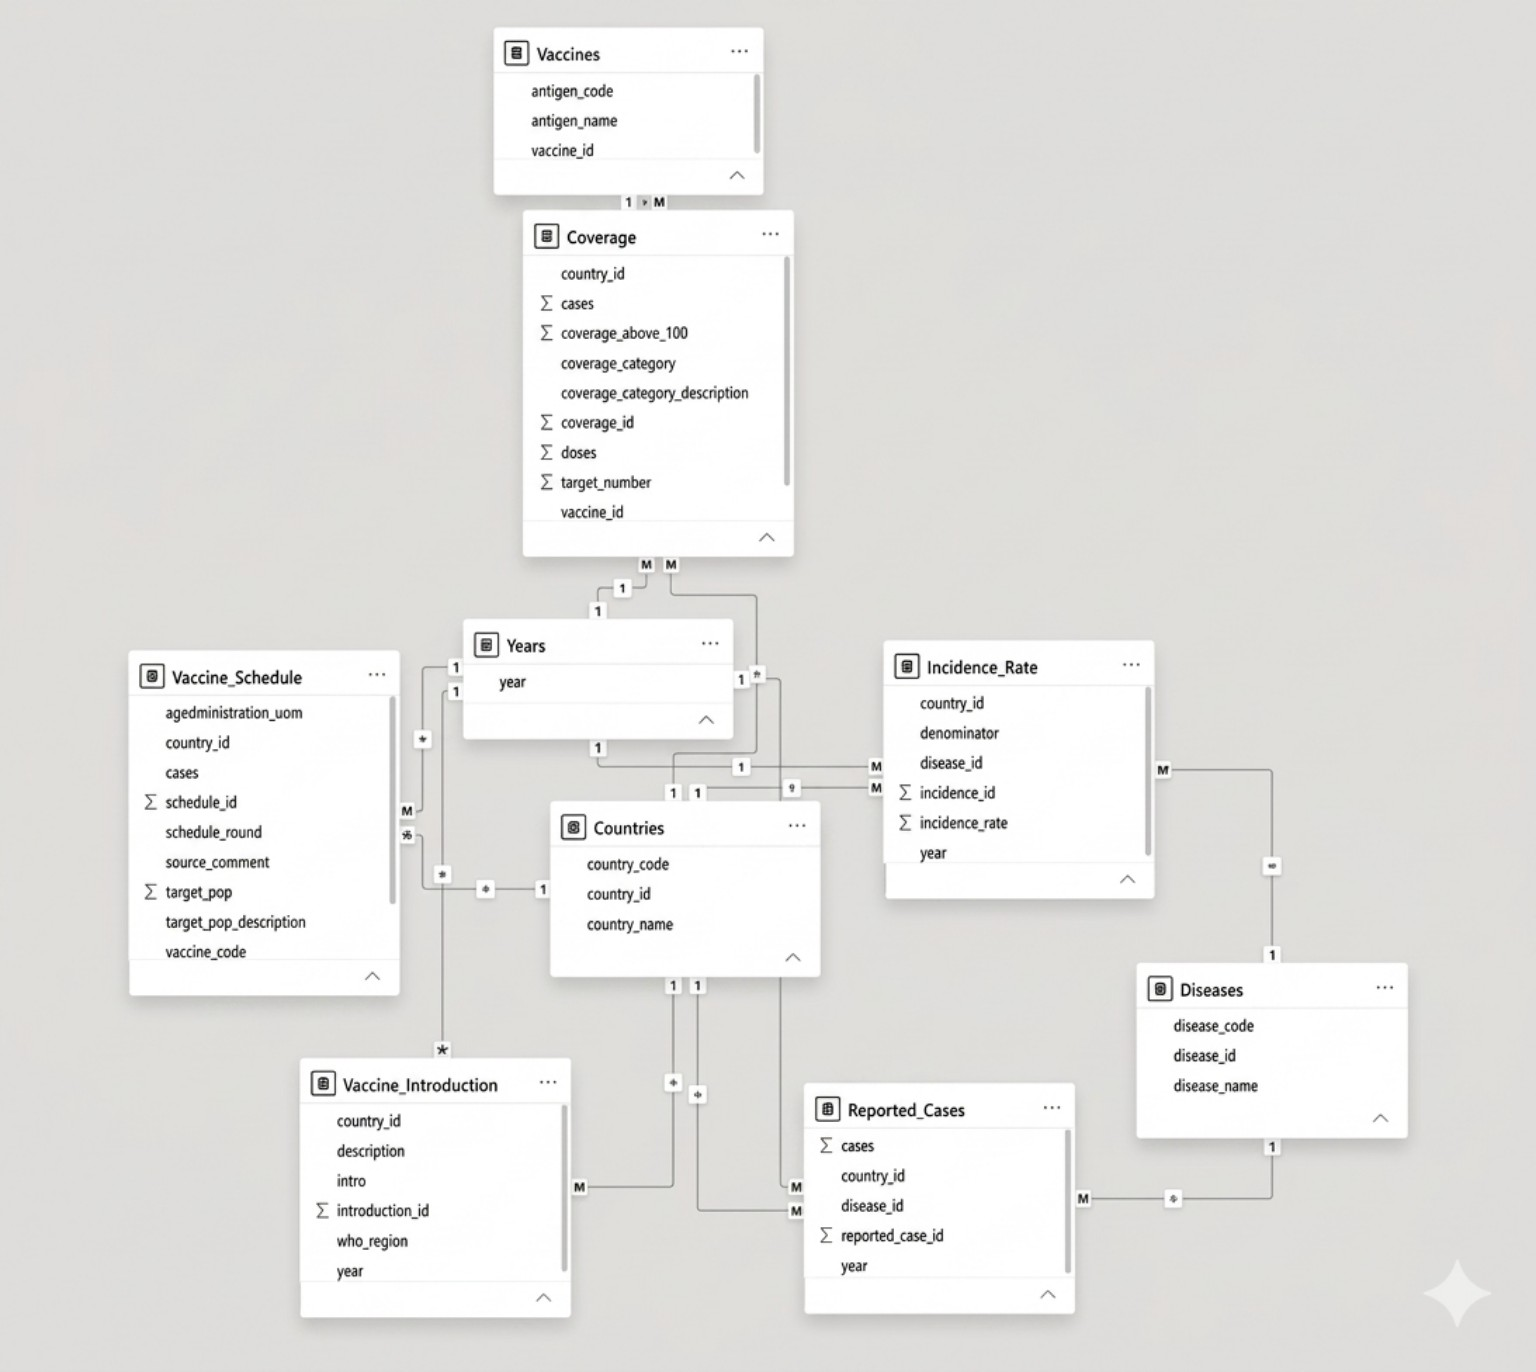

## Power BI Integration



Power BI was connected to the cleaned and normalized SQL database to create interactive dashboards for vaccination and disease analysis.

The SQL database contains separate tables for countries, years, diseases, vaccines, vaccination coverage, disease incidence, reported cases, vaccine introduction, and vaccine schedules.

The Power BI data model was created using the relationships between these tables. The model supports analysis of vaccination coverage, disease incidence, reported cases, vaccine introduction, and vaccination schedules.

Interactive filters and slicers were used to allow users to explore the data across different years, countries, diseases, and vaccination measures.

The dashboards were designed according to the visualization requirements specified in the project report, including KPI indicators, bar charts, line charts, scatter plots, and geographical maps.

## Power BI Dashboard Pages



Six interactive Power BI dashboard pages were created:

1. **Overview**
   - Key project-level KPIs
   - Vaccination coverage trend
   - Reported cases trend
   - Disease incidence trend

2. **Vaccination Coverage**
   - Countries with comparatively low vaccination coverage
   - Antigens with comparatively low vaccination coverage

3. **Disease Incidence & Cases**
   - Countries with high measles incidence
   - Reported cases by disease
   - Disease incidence trends

4. **Vaccine Introduction & Schedule**
   - Vaccine introduction records over time
   - Vaccine introduction status distribution
   - Vaccine schedule records by target population

5. **Coverage & Incidence Relationship**
   - Vaccination coverage versus measles incidence
   - Vaccination coverage trend
   - Reported cases trend
   - Measles incidence trend

6. **Geographical Analysis**
   - Average vaccination coverage by country
   - Average measles incidence rate by country
   - Year range slicer for interactive exploration

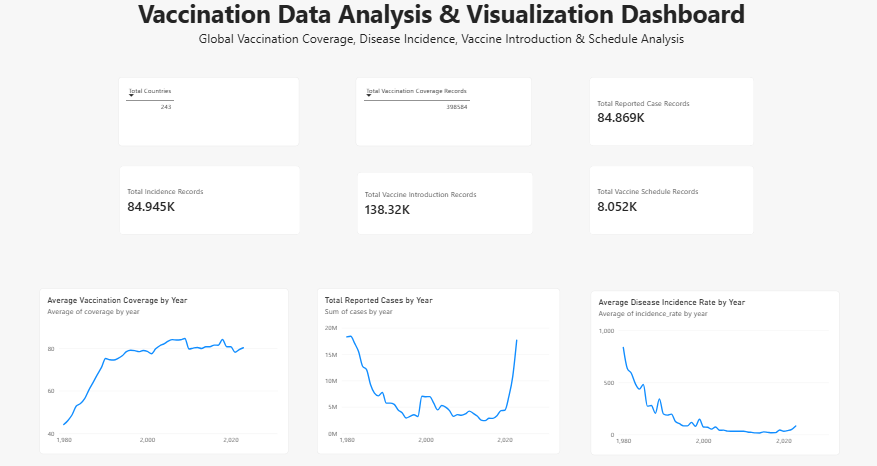

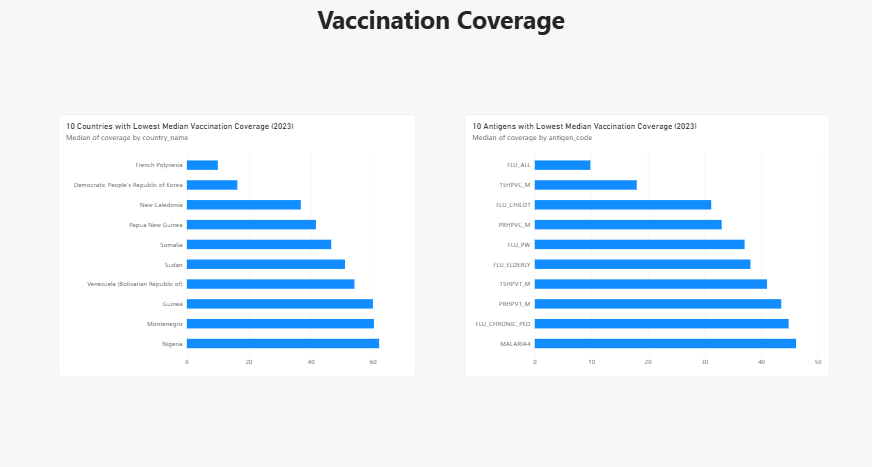

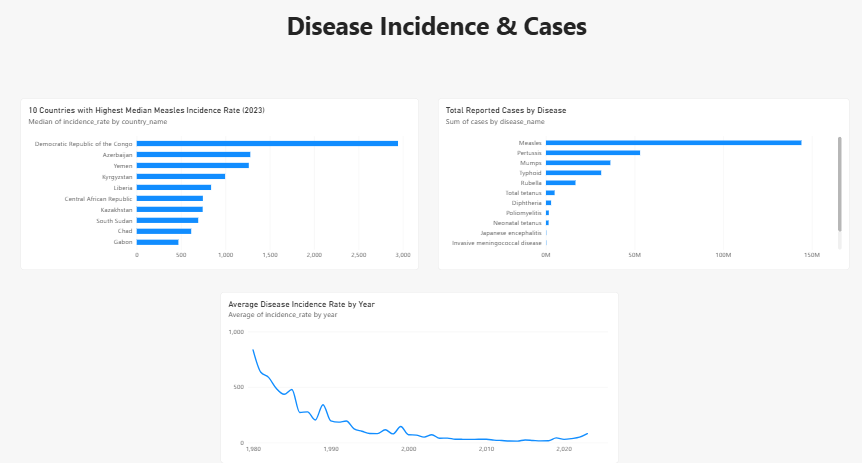

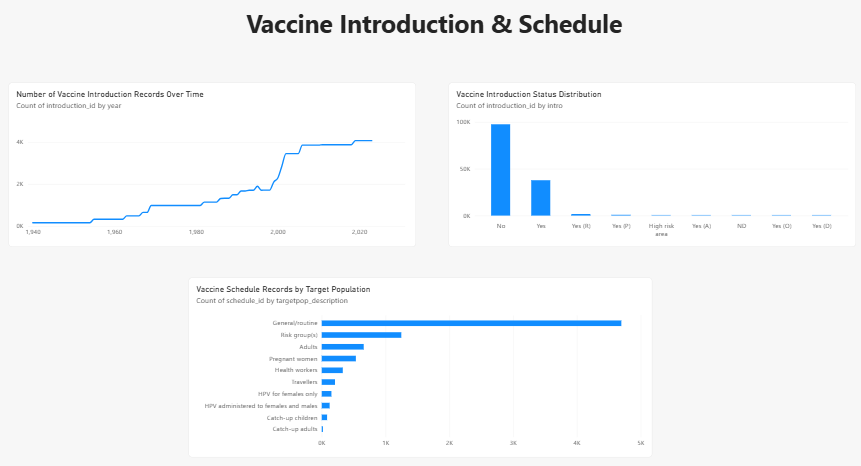

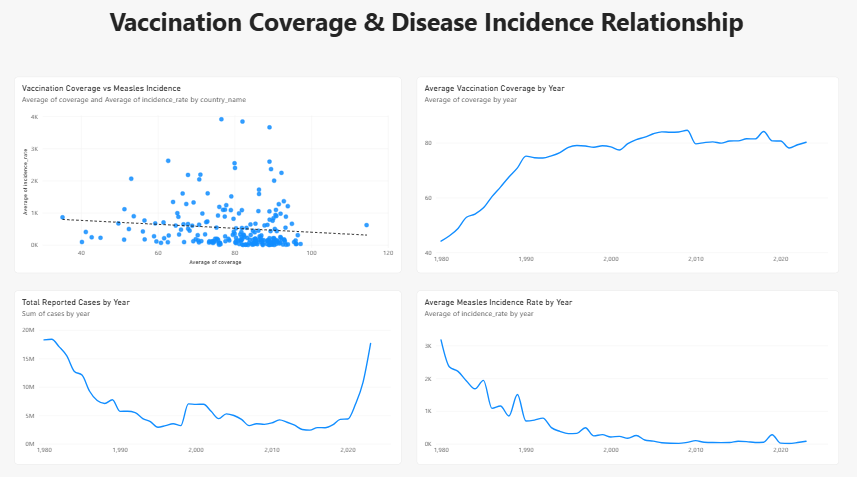

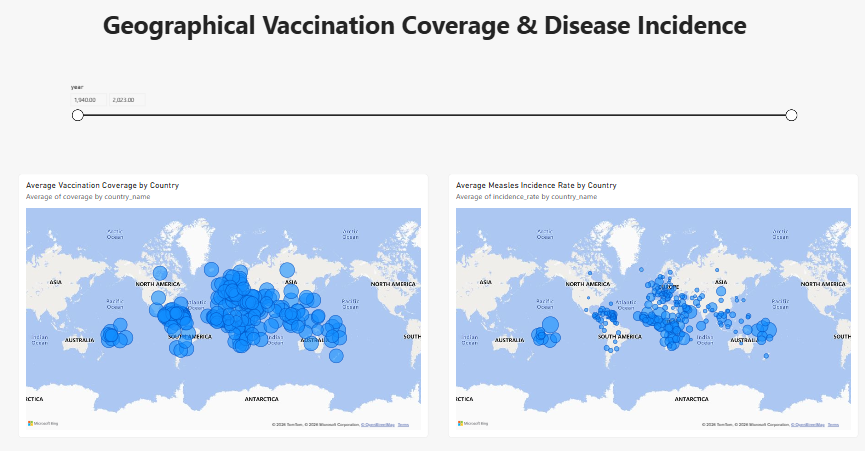

## Power BI Visualization Summary



The Power BI report provides interactive visual analysis of the cleaned vaccination datasets.

The report includes KPI cards, bar charts, line charts, a scatter plot with a trend line, geographical maps, and an interactive year slicer.

The visualizations help examine vaccination coverage, disease incidence, reported cases, vaccine introduction patterns, vaccination schedules, country-level differences, and relationships between vaccination coverage and measles incidence.

The Power BI dashboards provide the visualization layer for the cleaned SQL database and complement the Python-based exploratory data analysis performed earlier in the project.

##  **Conclusion**



This project analyzed five vaccination-related datasets covering vaccination coverage, disease incidence rates, reported cases, vaccine introductions, and vaccine schedules.

The data preparation process included loading the datasets, standardizing column names and year fields, removing metadata/footer records, checking duplicate records, identifying missing values, investigating invalid values, and preserving legitimate missing observations without inappropriate assumptions.

Exploratory Data Analysis (EDA) was performed to examine vaccination coverage, disease incidence, reported cases, country-level differences, antigen-level coverage, vaccine introduction patterns, vaccination schedules, and relationships between vaccination coverage and measles outcomes.

The analysis identified comparatively low vaccination coverage across selected countries and antigens, variation in measles incidence between countries, changes in vaccination coverage and reported cases over time, and patterns in vaccine introduction and target populations.

A normalized SQL database was created to organize the cleaned data into separate tables for countries, years, diseases, vaccines, vaccination coverage, incidence rates, reported cases, vaccine introduction, and vaccine schedules. Primary and foreign-key relationships were used to maintain referential integrity, and foreign-key integrity checks confirmed that no orphan records were present in the implemented relationships.

Power BI was then connected to the SQL database to create interactive dashboards. The final report contains six pages covering the overall project overview, vaccination coverage, disease incidence and cases, vaccine introduction and schedules, the relationship between vaccination coverage and measles incidence, and geographical analysis.

The relationship analysis showed an inverse association between vaccination coverage and measles incidence in the matched country-year observations used in the EDA. However, the observed relationship does not establish that vaccination coverage alone causes changes in disease incidence, as other factors may also contribute to disease outcomes.

Overall, the project provides a structured data-analysis workflow combining Python, SQL, and Power BI. The resulting cleaned datasets, normalized database, exploratory analysis, and interactive dashboards can support public-health monitoring, identification of areas requiring further investigation, resource planning, and evaluation of vaccination-related trends.